# Projet compagnon — Modèle de Vasicek  
## Résolution par EDP, schémas numériques et calibration

---

## 1. Objectif du notebook

Ce notebook constitue une étude complète et **autosuffisante** du modèle de Vasicek pour la valorisation d’une obligation zéro-coupon.

L’objectif est double :

1. Vérifier dans quelle mesure la résolution numérique de l’équation aux dérivées partielles (EDP) associée au modèle de Vasicek reproduit fidèlement la solution analytique connue.
2. Analyser les limites pratiques du modèle lorsqu’il est calibré sur une courbe de taux réelle.

Le fil directeur est donc le suivant :

> *Dans quelle mesure la résolution numérique de l’EDP du modèle de Vasicek permet-elle de reproduire ses propriétés analytiques, et quelles limites apparaissent lors de la calibration à des données de marché ?*

---

## 2. Dynamique du taux court

Sous la mesure risque-neutre, le modèle de Vasicek suppose que le taux court $ r_t $ suit la dynamique stochastique :

$$
dr_t = a(b - r_t)\,dt + \sigma\,dW_t,
$$

où :

- $a > 0 $ : vitesse de rappel vers le niveau de long terme,
- $ b $ : niveau de long terme du taux,
- $ \sigma > 0 $ : volatilité,
- $ W_t $ : mouvement brownien standard sous la mesure risque-neutre.

Ce modèle est :

- **gaussien** (le taux peut devenir négatif),
- **à réversion vers la moyenne**,
- **affine**, ce qui permet l’obtention d’une solution analytique fermée pour les obligations zéro-coupon.

---

## 3. Plan du notebook

Le notebook est structuré comme suit :

1. Rappel de la solution analytique du zéro-coupon.
2. Passage de l’EDS à l’EDP de pricing.
3. Discrétisation numérique (espace et temps).
4. Implémentation des schémas :
   - Euler implicite,
   - Euler explicite (illustration CFL),
   - Crank–Nicolson.
5. Validation numérique :
   - positivité,
   - monotonie,
   - comparaison à la solution analytique,
   - étude de convergence.
6. Calibration sur une courbe de taux réelle.
7. Analyse de sensibilité des paramètres.
8. Discussion des limites structurelles du modèle.

---

## 4. Stratégie méthodologique

Nous suivrons la chaîne logique complète :

- **Modélisation stochastique** →  
- **Formule de Feynman–Kac** →  
- **EDP parabolique de pricing** →  
- **Discrétisation par différences finies** →  
- **Résolution numérique forward en maturité** →  
- **Validation par benchmark analytique** →  
- **Calibration et analyse économique**

L’objectif est de relier rigueur mathématique, stabilité numérique et intuition financière.

In [77]:
# ============================================================
# Librairies scientifiques utilisées
# ============================================================

# Calcul numérique vectorisé
import numpy as np

# Manipulation éventuelle de données de marché (calibration)
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # nécessaire pour surfaces 3D

# Algèbre linéaire creuse (résolution des systèmes tridiagonaux)
from scipy import sparse
from scipy.sparse.linalg import splu

# Calibration par moindres carrés non linéaires
from scipy.optimize import least_squares


# ============================================================
# Paramètres graphiques globaux
# ============================================================

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# 1. Introduction — Cadre mathématique

Nous considérons le modèle de **Vasicek** pour la dynamique du taux court $ r_t $ sous la mesure risque-neutre $ \mathbb{Q} $ :

$$
dr_t = a(b - r_t)\,dt + \sigma\,dW_t,
$$

où :

- $a > 0$ désigne la vitesse de rappel vers la moyenne ;
- $b$ représente le niveau de long terme du taux ;
- $\sigma > 0$ correspond à la volatilité ;
- $(W_t)_{t\ge 0}$ est un mouvement brownien standard sous la mesure $\mathbb{Q}$.

---

## 1.1 Propriétés essentielles du modèle

Cette dynamique présente trois caractéristiques fondamentales :

- **Réversion vers la moyenne** : le taux tend vers $ b $.
- **Gaussianité** : $ r_t $ est normalement distribué (possibilité de taux négatifs).
- **Structure affine** : les prix obligataires auront une forme exponentielle affine.

La solution explicite du taux court est :

$$
r_t = r_0 e^{-a t} + b(1 - e^{-a t}) + 
\sigma \int_0^t e^{-a(t-s)} dW_s.
$$

On en déduit :

$$
\mathbb{E}[r_t] = b + (r_0 - b)e^{-a t},
$$

$$
\mathrm{Var}(r_t) = \frac{\sigma^2}{2a}\left(1 - e^{-2at}\right).
$$

Ces expressions justifient le caractère stationnaire du modèle à long terme.

---

## 1.2 Problème étudié

On s’intéresse au prix d’une obligation zéro-coupon de maturité $ T $ :

$$
P(t,r) = \mathbb{E}^{\mathbb{Q}}\left[
\exp\left(-\int_t^T r_s ds\right)
\middle| r_t = r
\right],
$$

avec condition terminale :

$$
P(T,r) = 1.
$$

Par la formule de Feynman–Kac, ce prix satisfait une EDP parabolique :

$$
\frac{\partial P}{\partial t}
+ a(b-r)\frac{\partial P}{\partial r}
+ \frac{1}{2}\sigma^2 \frac{\partial^2 P}{\partial r^2}
- rP = 0.
$$

---

## 1.3 Objectif numérique

Le cœur du notebook est le suivant :

1. Résoudre numériquement cette EDP par différences finies.
2. Comparer les solutions numériques à la solution analytique fermée.
3. Étudier les propriétés numériques (stabilité, convergence).
4. Calibrer le modèle sur une courbe de taux réelle.
5. Analyser les limites structurelles du modèle.

La solution analytique du zéro-coupon servira de **benchmark de validation** pour l’ensemble des schémas numériques.

# 2. Théorie — EDP et solution analytique

Nous rappelons ici les éléments théoriques nécessaires à la validation numérique.

---

## 2.1 Équation aux dérivées partielles de pricing

Le prix d’un zéro-coupon s’écrit :

$$
P(t,r) = \mathbb{E}^{\mathbb{Q}}\!\left[
\exp\!\left(-\int_t^T r_s ds\right)
\middle| r_t = r
\right].
$$

Par la formule de Feynman–Kac, $ P(t,r) $ satisfait l’EDP parabolique :

$$
\frac{\partial P}{\partial t}
+ a(b-r)\frac{\partial P}{\partial r}
+ \frac{1}{2}\sigma^2 \frac{\partial^2 P}{\partial r^2}
- rP = 0,
\qquad P(T,r)=1.
$$

Cette équation possède la structure :

- **Transport (dérive)** : $ a(b-r)\partial_r P $
- **Diffusion** : $ \frac12\sigma^2 \partial_{rr} P $
- **Réaction (actualisation)** : $ -rP $

Il s’agit d’une **EDP parabolique**, ce qui justifie l’utilisation de schémas implicites pour sa résolution numérique.

---

## 2.2 Changement de variable : temps restant

Afin de transformer la condition terminale en condition initiale, on introduit :

$$
\tau = T - t,
\qquad
u(\tau,r) = P(T-\tau,r).
$$

On obtient alors :

$$
u(0,r) = 1.
$$

En utilisant $ \partial_t P = -\partial_\tau u $, l’EDP devient :

$$
\partial_\tau u
=
a(b-r)\partial_r u
+ \frac12 \sigma^2 \partial_{rr} u
- r u.
$$

Cette formulation est **forward en maturité** et sera utilisée pour la discrétisation numérique.

---

## 2.3 Solution analytique fermée

Le modèle de Vasicek appartient à la classe des **modèles affines**.  
On cherche donc une solution de la forme :

$$
u(\tau,r) = A(\tau)\,e^{-B(\tau) r}.
$$

En injectant cette forme dans l’EDP et en identifiant les coefficients en $ r $, on obtient le système :

$$
B'(\tau) = 1 - aB(\tau), 
\qquad B(0)=0,
$$

$$
\frac{A'(\tau)}{A(\tau)}
=
-ab B(\tau)
+ \frac12 \sigma^2 B(\tau)^2,
\qquad A(0)=1.
$$

La résolution donne :

$$
B(\tau)
=
\frac{1-e^{-a\tau}}{a},
$$

$$
A(\tau)
=
\exp\!\left[
\left(b-\frac{\sigma^2}{2a^2}\right)(B(\tau)-\tau)
-
\frac{\sigma^2}{4a}B(\tau)^2
\right].
$$

Finalement :

$$
P(t,T)
=
A(T-t)\,
\exp\!\big(-B(T-t)\,r_t\big).
$$

---

## 2.4 Rôle de la solution analytique

Cette solution fermée servira de **benchmark de référence** pour :

- mesurer l’erreur numérique,
- vérifier la convergence,
- valider la stabilité des schémas,
- analyser la précision temporelle et spatiale.

Elle constitue donc l’outil central de validation du solveur EDP.

## 2.5 Implémentation de la solution analytique

Nous implémentons maintenant les fonctions analytiques :

- $B(\tau)$  
- $A(\tau)$  
- le prix du zéro-coupon $P(t,r)$  
- le taux spot associé $R(t,T)$  

Ces fonctions serviront de **référence numérique** pour :

- mesurer les erreurs des schémas EDP,
- tester la convergence,
- valider la calibration.

On veille à :

- autoriser des entrées scalaires ou vectorielles,
- garantir la stabilité numérique pour $ \tau \to 0 $,
- conserver une cohérence stricte avec les formules théoriques.

In [78]:
# ============================================================
# Solution analytique du modèle de Vasicek
# ============================================================

def B_vasicek(tau, a):
    """
    Fonction B(τ) = (1 - e^{-a τ}) / a
    """
    tau = np.asarray(tau, dtype=float)
    return (1.0 - np.exp(-a * tau)) / a


def A_vasicek(tau, a, b, sigma):
    """
    Fonction A(τ) du modèle affine de Vasicek.
    """
    tau = np.asarray(tau, dtype=float)
    Btau = B_vasicek(tau, a)

    term1 = (b - sigma**2 / (2 * a**2)) * (Btau - tau)
    term2 = - (sigma**2 / (4 * a)) * (Btau**2)

    return np.exp(term1 + term2)


def P_analytic(t, r, T, a, b, sigma):
    """
    Prix analytique d’un zéro-coupon P(t,r) de maturité T.
    Compatible scalaire / vectoriel.
    """
    tau = T - t
    return A_vasicek(tau, a, b, sigma) * np.exp(-B_vasicek(tau, a) * r)


def R_spot_analytic(t, T, r0, a, b, sigma):
    """
    Taux spot R(t,T) = - ln P(t,T) / (T - t)
    avec r_t = r0.
    """
    tau = T - t

    # Sécurité numérique si tau est très petit
    if np.isclose(tau, 0.0):
        return r0

    P = P_analytic(t, r0, T, a, b, sigma)
    return -np.log(P) / tau

# 3. Méthodes numériques — Discrétisation de l’EDP

Nous cherchons à résoudre numériquement l’EDP forward :

$$
\partial_\tau u
=
a(b-r)\partial_r u
+
\frac12\sigma^2\partial_{rr}u
-
r u.
$$

L’objectif est de construire une approximation discrète sur une grille
$ (\tau_n, r_i) $.

---

## 3.1 Domaine et grilles

Le taux court est théoriquement défini sur $ \mathbb{R} $.
Une implémentation numérique nécessite une **troncature** :

$$
r \in [r_{\min}, r_{\max}].
$$

Le choix de cet intervalle repose sur le caractère gaussien du modèle :

$$
r_T \sim \mathcal{N}\!\left(
b + (r_0-b)e^{-aT},
\frac{\sigma^2}{2a}(1-e^{-2aT})
\right).
$$

On choisit donc un domaine couvrant plusieurs écarts-types autour de l’espérance
(typiquement 4 ou 5), afin de rendre l’erreur de troncature négligeable.

---

### Discrétisation spatiale

$$
r_i = r_{\min} + i\,\Delta r,
\qquad i = 0,\dots,M,
$$

avec :

$$
\Delta r = \frac{r_{\max} - r_{\min}}{M}.
$$

---

### Discrétisation temporelle

$$
\tau_n = n\,\Delta\tau,
\qquad n = 0,\dots,N,
$$

avec :

$$
\Delta\tau = \frac{T}{N}.
$$

On note :

$$
u_i^n \approx u(\tau_n, r_i).
$$

---

## 3.2 Discrétisation spatiale : différences finies centrées

On utilise des différences centrées d’ordre 2 :

$$
\partial_r u(\tau_n,r_i)
\approx
\frac{u_{i+1}^n - u_{i-1}^n}{2\Delta r},
$$

$$
\partial_{rr}u(\tau_n,r_i)
\approx
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta r^2}.
$$

Ce choix est cohérent avec :

- la régularité de la solution (zéro-coupon),
- la recherche d’un ordre 2 en espace,
- la symétrie naturelle du terme diffusif.

---

## 3.3 Construction de l’opérateur discret

On note l’opérateur continu :

$$
\mathcal{L}u
=
a(b-r)\partial_r u
+
\frac12\sigma^2\partial_{rr}u
-
r u.
$$

Après substitution des différences finies, on obtient une approximation linéaire :

$$
(\mathcal{L}u)(\tau_n,\cdot)
\approx
L\,u^n,
$$

où $ L $ est une **matrice tridiagonale**.

Pour un point intérieur $ i $, les coefficients sont :

---
### Coefficient sur $u_{i-1}$

$$
\alpha_i
=
\frac{\sigma^2}{2\Delta r^2}
-
\frac{a(b-r_i)}{2\Delta r}
$$

---

### Coefficient sur $u_i$

$$
\beta_i
=
-
\frac{\sigma^2}{\Delta r^2}
-
r_i
$$

---

### Coefficient sur $u_{i+1}$

$$
\gamma_i
=
\frac{\sigma^2}{2\Delta r^2}
+
\frac{a(b-r_i)}{2\Delta r}
$$
---

## 3.4 Structure numérique obtenue

L’opérateur discret possède la structure :

- matrice creuse,
- tridiagonale,
- dépendant uniquement de la grille spatiale,
- indépendante du temps.

Cette structure permettra une résolution efficace par factorisation LU creuse.

## 3.5 Conditions aux limites et opérateur discret

Nous résolvons numériquement :

$$
\partial_\tau u = \mathcal{L}u
\quad \text{avec} \quad
\mathcal{L}u = a(b-r)\partial_r u + \frac12\sigma^2\partial_{rr}u - r u.
$$

La grille spatiale est tronquée à $[r_{\min}, r_{\max}]$.  
Nous imposons des **conditions de Neumann homogènes** :

$$
\partial_r u(\tau, r_{\min}) = 0,
\qquad
\partial_r u(\tau, r_{\max}) = 0.
$$

Avec une discrétisation centrée, cela se traduit numériquement par :

$$
u_0^n = u_1^n,
\qquad
u_M^n = u_{M-1}^n.
$$

**Choix d’implémentation :** plutôt que de modifier explicitement la matrice aux bords, on résout le système sur la grille puis on **projette** la solution à chaque pas de temps en imposant les égalités ci-dessus.  
À l’ordre de discrétisation considéré, cette stratégie est stable et très simple à maintenir.

In [79]:
# ============================================================
# Construction de l'opérateur discret et solveurs PDE (Vasicek)
# ============================================================

def build_operator_L(r_grid, a, b, sigma):
    """
    Construit la matrice creuse tridiagonale L (format CSC) telle que :

        du/dtau = L u

    Discrétisation : différences finies centrées sur l'espace (points intérieurs).
    Aux bords, l'opérateur est laissé nul et les conditions de Neumann homogènes
    sont imposées a posteriori via `enforce_neumann`.
    """
    r = np.asarray(r_grid, dtype=float)
    M = len(r) - 1

    # Vérification grille uniforme
    dr = r[1] - r[0]
    if not np.allclose(np.diff(r), dr):
        raise ValueError("r_grid doit être uniformément espacée (pas constant).")

    # Points intérieurs i = 1..M-1
    idx = np.arange(1, M)
    ri = r[idx]

    alpha = 0.5 * sigma**2 / dr**2 - a * (b - ri) / (2 * dr)   # sur u_{i-1}
    beta  = - sigma**2 / dr**2 - ri                            # sur u_i
    gamma = 0.5 * sigma**2 / dr**2 + a * (b - ri) / (2 * dr)   # sur u_{i+1}

    # Matrice (M+1)x(M+1) : bords laissés à 0 (gérés par enforce_neumann)
    lower = np.zeros(M+1); lower[1:M] = alpha
    diag  = np.zeros(M+1); diag[1:M]  = beta
    upper = np.zeros(M+1); upper[1:M] = gamma

    L = sparse.diags(
        diagonals=[lower[1:], diag, upper[:-1]],
        offsets=[-1, 0, 1],
        shape=(M+1, M+1),
        format="csc"
    )
    return L


def enforce_neumann(u):
    """
    Impose les conditions de Neumann homogènes discrètes :
        u_0 = u_1  et  u_M = u_{M-1}.
    """
    u = u.copy()
    u[0] = u[1]
    u[-1] = u[-2]
    return u


def solve_pde_euler_implicit(T, r_grid, Nt, a, b, sigma):
    """
    Schéma d'Euler implicite sur tau ∈ [0, T] :

        (I - Δτ L) u^{n+1} = u^n,     u^0 = 1.

    Retourne :
        tau_grid (Nt+1,), U (Nt+1, M+1) avec U[n,i] ≈ u(tau_n, r_i).
    """
    r = np.asarray(r_grid, dtype=float)
    M = len(r) - 1

    dtau = T / Nt
    tau = np.linspace(0.0, T, Nt + 1)

    L = build_operator_L(r, a, b, sigma)
    I = sparse.eye(M + 1, format="csc")
    A = (I - dtau * L)

    lu = splu(A)

    U = np.zeros((Nt + 1, M + 1), dtype=float)
    U[0, :] = enforce_neumann(np.ones(M + 1))

    for n in range(Nt):
        u_next = lu.solve(U[n, :])
        U[n + 1, :] = enforce_neumann(u_next)

    return tau, U


def solve_pde_crank_nicolson(T, r_grid, Nt, a, b, sigma):
    """
    Schéma de Crank–Nicolson sur tau ∈ [0, T] :

        (I - Δτ/2 L) u^{n+1} = (I + Δτ/2 L) u^n,     u^0 = 1.

    Retourne :
        tau_grid (Nt+1,), U (Nt+1, M+1).
    """
    r = np.asarray(r_grid, dtype=float)
    M = len(r) - 1

    dtau = T / Nt
    tau = np.linspace(0.0, T, Nt + 1)

    L = build_operator_L(r, a, b, sigma)
    I = sparse.eye(M + 1, format="csc")

    A = (I - 0.5 * dtau * L)
    B = (I + 0.5 * dtau * L)

    lu = splu(A)

    U = np.zeros((Nt + 1, M + 1), dtype=float)
    U[0, :] = enforce_neumann(np.ones(M + 1))

    for n in range(Nt):
        rhs = B @ U[n, :]
        u_next = lu.solve(rhs)
        U[n + 1, :] = enforce_neumann(u_next)

    return tau, U

## 3.6 Passage de $u(\tau,r)$ à $P(t,r)$

Nous avons introduit le temps restant :

$$
\tau = T - t,
\qquad
u(\tau,r) = P(T-\tau, r).
$$

Cette relation se réécrit directement :

$$
P(t,r) = u(T-t, r).
$$

---

### Conséquence numérique (grille)

Dans l’implémentation, nous résolvons l’EDP **forward en $\tau$** :

- on part de $\tau = 0$ avec la condition initiale $u(0,r)=1$,
- on progresse jusqu’à $\tau = T$.

La quantité d’intérêt au temps initial $t=0$ est alors :

$$
P(0,r) = u(T,r).
$$

Autrement dit, dans le tableau discret $U[n,i] \approx u(\tau_n,r_i)$ :

- la ligne $n=0$ correspond à $t=T$ (maturité),
- la ligne $n=N$ correspond à $t=0$ (aujourd’hui).

On récupère donc le prix à $t=0$ via :

$$
P(0,r_i) \approx U[N,i].
$$

## 3.7 Conversion $\tau \mapsto t$ et métriques d'erreur

Les solveurs numériques calculent $u(\tau,r)$ sur une grille en $\tau$.
Pour comparer à la solution analytique $P(t,r)$ (définie en temps calendrier $t$),
on utilise :

$$
P(t,r) = u(T-t,r).
$$

Sur la grille discrète, cela correspond à un simple **renversement** de l’axe temporel.

Nous définissons également deux métriques d’erreur globales entre une solution numérique et une référence :

- erreur en norme $L^\infty$ (max),
- erreur de type $L^2$ discrète (RMSE).

In [80]:
# ============================================================
# Outils : conversion tau -> t et métriques d'erreur
# ============================================================

def U_to_P(t_grid, tau_grid, U):
    """
    Convertit une solution calculée en tau (U[n,i] ≈ u(tau_n, r_i))
    en une solution en temps calendrier t (P[k,i] ≈ P(t_k, r_i)).

    Relation : tau = T - t  =>  P(t, r) = u(T - t, r)

    Si t_grid et tau_grid ont même longueur (Nt+1), alors :
        P(t_n, r) = U(tau_{Nt-n}, r)

    Numériquement : renversement de l'axe temporel.
    """
    t_grid = np.asarray(t_grid, dtype=float)
    tau_grid = np.asarray(tau_grid, dtype=float)
    U = np.asarray(U, dtype=float)

    if len(t_grid) != len(tau_grid):
        raise ValueError("t_grid et tau_grid doivent avoir la même longueur (Nt+1).")

    # renversement de la dimension temporelle
    return U[::-1, :].copy()


def linf_error(u_num, u_ref):
    """
    Erreur globale de type L_infty :
        ||e||_inf = max_i |u_num - u_ref|
    """
    u_num = np.asarray(u_num, dtype=float)
    u_ref = np.asarray(u_ref, dtype=float)

    if u_num.shape != u_ref.shape:
        raise ValueError("u_num et u_ref doivent avoir la même forme.")

    return np.max(np.abs(u_num - u_ref))


def l2_error(u_num, u_ref):
    """
    Erreur globale de type L2 discrète (ici RMSE) :
        sqrt( mean_i (u_num - u_ref)^2 )
    """
    u_num = np.asarray(u_num, dtype=float)
    u_ref = np.asarray(u_ref, dtype=float)

    if u_num.shape != u_ref.shape:
        raise ValueError("u_num et u_ref doivent avoir la même forme.")

    e = u_num - u_ref
    return np.sqrt(np.mean(e**2))

## 3.8 Schéma d’Euler explicite — contrainte de stabilité (CFL)

À titre illustratif, on considère également le schéma d’Euler explicite appliqué à :

$$
\partial_\tau u = L u.
$$

Il s’écrit :

$$
\frac{u^{n+1} - u^n}{\Delta\tau}
=
L u^n,
$$

soit :

$$
u^{n+1}
=
u^n + \Delta\tau\, L u^n.
$$

---

### Propriété essentielle : stabilité conditionnelle

Contrairement aux schémas implicites, Euler explicite est **conditionnellement stable**.

Dans le cas d’une EDP de type dérive–diffusion–réaction, la contrainte la plus restrictive provient généralement du terme diffusif :

$$
\Delta\tau
\;\lesssim\;
\frac{\Delta r^2}{\sigma^2}.
$$

Cette condition est analogue à la condition CFL classique des équations de diffusion.

Si cette contrainte n’est pas respectée :

- oscillations numériques,
- valeurs négatives,
- explosion de la solution.

---

### Rôle dans ce notebook

Le schéma explicite est utilisé ici uniquement :

- pour illustrer la contrainte CFL,
- pour montrer expérimentalement l’instabilité,
- comme point de comparaison pédagogique.

Les calculs robustes seront effectués avec :

- Euler implicite (stable inconditionnellement),
- Crank–Nicolson (ordre 2 en temps).

In [81]:
# ============================================================
# Euler explicite (illustration CFL)
# ============================================================

def solve_pde_euler_explicit(T, r_grid, Nt, a, b, sigma):
    """
    Schéma d'Euler explicite sur tau ∈ [0, T] :

        u^{n+1} = u^n + Δτ L u^n,     u^0 = 1.

    ATTENTION : stable seulement si Δτ respecte une contrainte de type CFL.
    Cette fonction est utilisée ici à des fins pédagogiques (illustration instabilité).

    Retourne :
        tau_grid (Nt+1,), U (Nt+1, M+1) avec U[n,i] ≈ u(tau_n, r_i).
    """
    r = np.asarray(r_grid, dtype=float)
    M = len(r) - 1

    dtau = T / Nt
    tau = np.linspace(0.0, T, Nt + 1)

    L = build_operator_L(r, a, b, sigma)

    U = np.zeros((Nt + 1, M + 1), dtype=float)
    u = enforce_neumann(np.ones(M + 1))
    U[0, :] = u.copy()

    for n in range(Nt):
        u = u + dtau * (L @ u)
        u = enforce_neumann(u)
        U[n + 1, :] = u.copy()

    return tau, U

# 4. Analyses numériques — validations et visualisations

Dans cette section, nous mettons en œuvre les solveurs EDP et nous validons leur comportement numérique et économique.

---

## 4.1 Stratégie de validation

1. **Résolution numérique de l’EDP forward**  
   On calcule $u(\tau,r)$ sur une grille $(\tau_n,r_i)$ avec :
   - Euler implicite,
   - Crank–Nicolson,
   - (Euler explicite uniquement pour illustrer la contrainte CFL).

2. **Passage au prix en temps calendrier**  
   On utilise :
   $$
   P(t,r) = u(T-t,r),
   $$
   en particulier :
   $$
   P(0,r) = u(T,r).
   $$

3. **Benchmark analytique à $t=0$**  
   On compare $P_{\text{num}}(0,r)$ à la solution analytique $P_{\text{ana}}(0,r)$, et l’on mesure l’erreur :
   $$
   e(r_i) = P_{\text{num}}(0,r_i) - P_{\text{ana}}(0,r_i).
   $$

---

## 4.2 Tests de cohérence attendus

Au-delà de l’erreur numérique, on vérifie des propriétés essentielles :

- **Positivité** : $P(t,r) > 0$.
- **Monotonie** : à $t$ fixé, $r \mapsto P(t,r)$ doit être décroissante.
- **Conditions aux limites** : $u_0^n = u_1^n$ et $u_M^n = u_{M-1}^n$.
- **Stabilité** : absence d’oscillations parasites (en particulier pour Crank–Nicolson).

---

## 4.3 Visualisations

Nous produisons :

- des graphiques 2D : $r \mapsto P(0,r)$ (numérique vs analytique),
- des surfaces 3D : $(t,r) \mapsto P(t,r)$ pour visualiser l’évolution complète.

## 4.4 Choix des paramètres et des grilles

Nous fixons des paramètres représentatifs du modèle de Vasicek :

- $a = 0.10$ : vitesse de rappel modérée,
- $b = 5\%$ : niveau de long terme,
- $\sigma = 1\%$ : volatilité faible mais non négligeable,
- $T = 1$ an : maturité courte à moyenne.

---

### Domaine en taux

Le modèle étant gaussien, le taux peut devenir négatif.
On choisit donc un intervalle symétrique raisonnable :

$$
r \in [r_{\min}, r_{\max}]
=
[-2\%,\, 8\%],
$$

ce qui couvre largement les fluctuations typiques autour de $b=5\%$.

---

### Discrétisation spatiale

On prend $M=400$ points spatiaux, ce qui assure :

- une bonne résolution des dérivées secondes,
- une erreur spatiale négligeable par rapport à l’erreur temporelle.

---

### Discrétisation temporelle

- Euler implicite : $N_t = 200$,
- Crank–Nicolson : $N_t = 1000$.

On choisit un maillage plus fin pour Crank–Nicolson afin de
mettre en évidence son ordre 2 en temps et d’obtenir
une comparaison fine avec la solution analytique.

In [82]:
# ============================================================
# Paramètres du modèle (cas test)
# ============================================================

a = 0.10      # vitesse de rappel
b = 0.05      # niveau de long terme (5%)
sigma = 0.01  # volatilité
T = 1.0       # maturité (1 an)


# ============================================================
# Grille spatiale en r
# ============================================================

r_min, r_max = -0.02, 0.08
M = 400
r_grid = np.linspace(r_min, r_max, M + 1)

dr = r_grid[1] - r_grid[0]


# ============================================================
# Grilles temporelles
# ============================================================

Nt_euler = 200
Nt_cn = 1000

t_grid_euler = np.linspace(0.0, T, Nt_euler + 1)
t_grid_cn = np.linspace(0.0, T, Nt_cn + 1)

dtau_euler = T / Nt_euler
dtau_cn = T / Nt_cn

Le domaine en taux est choisi suffisamment large pour couvrir plusieurs écarts-types
du taux à maturité sous le modèle de Vasicek :

$$
r_T \sim \mathcal{N}\!\left(
b + (r_0-b)e^{-aT},
\frac{\sigma^2}{2a}(1-e^{-2aT})
\right).
$$

L’intervalle $[-2\%,\,8\%]$ couvre largement les fluctuations plausibles
autour du niveau de long terme $b$.

## 4.5 Résolution numérique et comparaison au benchmark analytique

Nous calculons :

- la solution numérique $u(\tau,r)$ avec Euler implicite et Crank–Nicolson,
- puis $P(t,r)$ via $P(t,r)=u(T-t,r)$,
- et enfin la solution analytique $P_{\text{ana}}(t,r)$ pour comparer.

La comparaison principale est effectuée à $t=0$ (temps initial), i.e. sur :

$$
r \mapsto P(0,r).
$$

Nous reportons l’erreur en norme $L^\infty$ :

$$
\|e\|_\infty = \max_i \left|P_{\text{num}}(0,r_i) - P_{\text{ana}}(0,r_i)\right|.
$$

In [83]:
# ============================================================
# Solveurs numériques : u(tau,r) puis conversion en P(t,r)
# ============================================================

tau_e, U_e = solve_pde_euler_implicit(T, r_grid, Nt_euler, a, b, sigma)
tau_c, U_c = solve_pde_crank_nicolson(T, r_grid, Nt_cn, a, b, sigma)

P_e = U_to_P(t_grid_euler, tau_e, U_e)
P_c = U_to_P(t_grid_cn, tau_c, U_c)


# ============================================================
# Benchmark analytique : P_ana(t,r) sur les mêmes grilles en t
# ============================================================

# P_analytic accepte r vectoriel, donc on vectorise sur t
P_ana_e = np.vstack([P_analytic(t, r_grid, T, a, b, sigma) for t in t_grid_euler])
P_ana_c = np.vstack([P_analytic(t, r_grid, T, a, b, sigma) for t in t_grid_cn])


# ============================================================
# Erreur à t = 0 (au temps initial)
# ============================================================

err_e_t0 = P_e[0, :] - P_ana_e[0, :]
err_c_t0 = P_c[0, :] - P_ana_c[0, :]

print(f"Euler implicite : ||e||_inf à t=0 = {linf_error(P_e[0,:], P_ana_e[0,:]):.3e}")
print(f"Crank–Nicolson : ||e||_inf à t=0 = {linf_error(P_c[0,:], P_ana_c[0,:]):.3e}")

Euler implicite : ||e||_inf à t=0 = 1.243e-02
Crank–Nicolson : ||e||_inf à t=0 = 5.135e-03


## 4.6 Comparaison à $t=0$ : prix et erreur

On compare la fonction :

$$
r \mapsto P(0,r)
$$

obtenue numériquement (Euler implicite / Crank–Nicolson) à la solution analytique.

On trace également l’erreur ponctuelle :

$$
e(r_i) = P_{\text{num}}(0,r_i) - P_{\text{ana}}(0,r_i),
$$

afin de vérifier :

- la stabilité (pas d’oscillations),
- la régularité de l’erreur,
- l’ordre de grandeur des écarts.

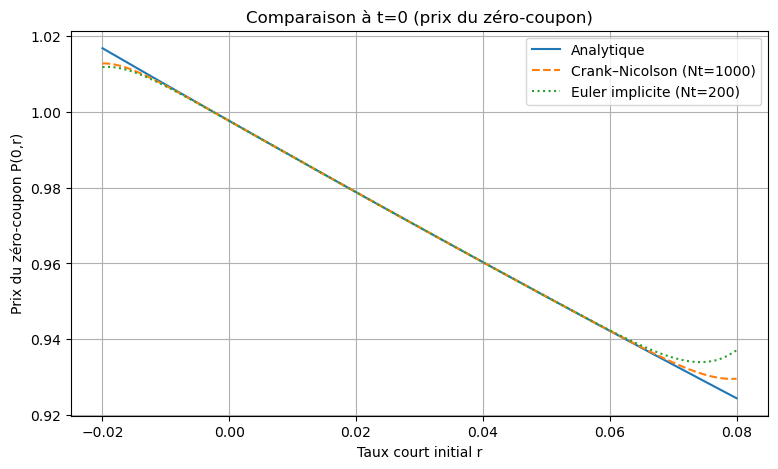

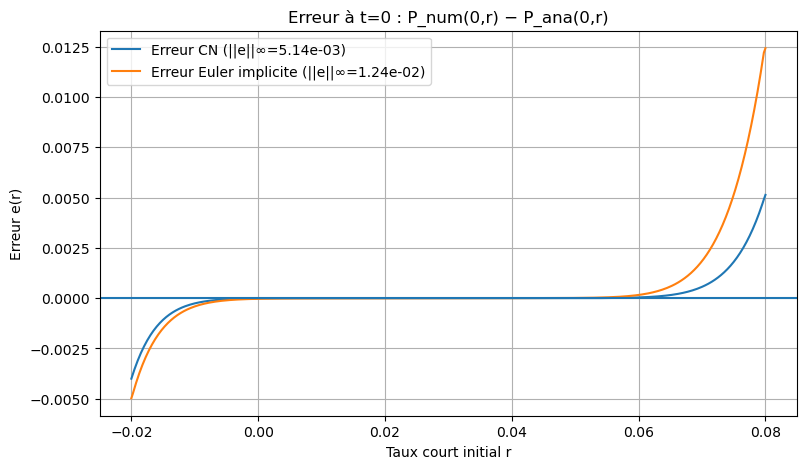

In [84]:
# ============================================================
# Comparaison à t = 0 : P(0,r)
# ============================================================

linf_e = linf_error(P_e[0, :], P_ana_e[0, :])
linf_c = linf_error(P_c[0, :], P_ana_c[0, :])

plt.figure()
plt.plot(r_grid, P_ana_c[0, :], label="Analytique")
plt.plot(r_grid, P_c[0, :], "--", label=f"Crank–Nicolson (Nt={Nt_cn})")
plt.plot(r_grid, P_e[0, :], ":", label=f"Euler implicite (Nt={Nt_euler})")
plt.xlabel("Taux court initial r")
plt.ylabel("Prix du zéro-coupon P(0,r)")
plt.title("Comparaison à t=0 (prix du zéro-coupon)")
plt.legend()
plt.show()


# ============================================================
# Erreurs à t = 0 (numérique - analytique)
# ============================================================

plt.figure()
plt.plot(r_grid, err_c_t0, label=f"Erreur CN (||e||∞={linf_c:.2e})")
plt.plot(r_grid, err_e_t0, label=f"Erreur Euler implicite (||e||∞={linf_e:.2e})")
plt.axhline(0.0)  # référence visuelle
plt.xlabel("Taux court initial r")
plt.ylabel("Erreur e(r)")
plt.title("Erreur à t=0 : P_num(0,r) − P_ana(0,r)")
plt.legend()
plt.show()

## 4.7 Visualisation 3D de la surface $(t,r) \mapsto P(t,r)$

Nous représentons la surface :

$$
(t,r) \longmapsto P(t,r),
$$

afin d’observer :

- la décroissance en fonction du taux $r$,
- la convergence vers $P(T,r)=1$ à maturité,
- la régularité temporelle de la solution.

Un sous-échantillonnage est utilisé pour améliorer la lisibilité graphique.

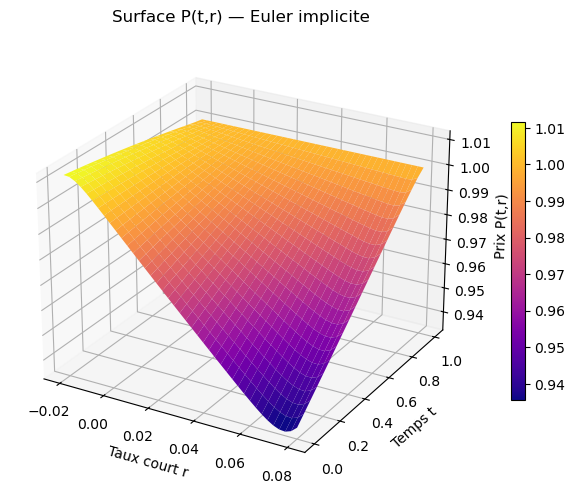

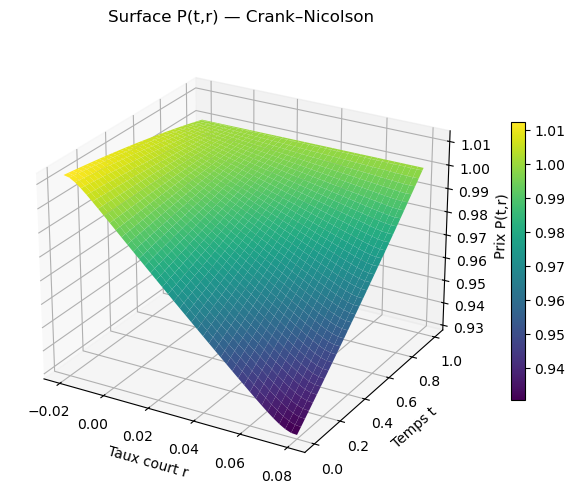

In [85]:
# ============================================================
# Visualisation 3D des surfaces P(t,r)
# ============================================================

def plot_surface_P(t_grid, r_grid, P, title, cmap="viridis"):
    Tm, Rm = np.meshgrid(t_grid, r_grid, indexing="ij")

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        Rm, Tm, P,
        cmap=cmap,
        linewidth=0,
        antialiased=True
    )

    ax.set_xlabel("Taux court r")
    ax.set_ylabel("Temps t")
    ax.set_zlabel("Prix P(t,r)")
    ax.set_title(title)
    ax.view_init(elev=25, azim=-60)

    fig.colorbar(surf, shrink=0.6)
    plt.show()


# ------------------------------------------------------------
# Sous-échantillonnage pour la lisibilité
# ------------------------------------------------------------

sub_t = slice(None, None, 10)
sub_r = slice(None, None, 10)

P_e_sub = P_e[sub_t, :][:, sub_r]
P_c_sub = P_c[sub_t, :][:, sub_r]

t_e_sub = t_grid_euler[sub_t]
t_c_sub = t_grid_cn[sub_t]
r_sub = r_grid[sub_r]


# ------------------------------------------------------------
# Surface Euler implicite
# ------------------------------------------------------------

plot_surface_P(
    t_e_sub,
    r_sub,
    P_e_sub,
    title="Surface P(t,r) — Euler implicite",
    cmap="plasma"
)


# ------------------------------------------------------------
# Surface Crank–Nicolson
# ------------------------------------------------------------

plot_surface_P(
    t_c_sub,
    r_sub,
    P_c_sub,
    title="Surface P(t,r) — Crank–Nicolson",
    cmap="viridis"
)

## 4.8 Démonstration numérique de la condition CFL (Euler explicite)

Le schéma d’Euler explicite :

$$
u^{n+1} = u^n + \Delta\tau\,L u^n
$$

est **conditionnellement stable**.  
Nous illustrons ce point en comparant :

- un pas de temps trop grand (instabilité),
- un pas de temps suffisamment petit (solution stable).

On reporte également des indicateurs simples (min/max), car l’instabilité se manifeste souvent par :

- apparition de valeurs négatives,
- oscillations,
- explosion des amplitudes.

In [86]:
# ============================================================
# Démonstration stabilité (Euler explicite) : dt trop grand vs dt petit
# ============================================================

T_demo = T
dr = r_grid[1] - r_grid[0]

# 1) Pas de temps trop grand (souvent instable)
Nt_bad = 30
tau_bad, U_bad = solve_pde_euler_explicit(T_demo, r_grid, Nt_bad, a, b, sigma)

# 2) Pas de temps plus fin (stable)
Nt_good = 2000
tau_good, U_good = solve_pde_euler_explicit(T_demo, r_grid, Nt_good, a, b, sigma)

dt_bad = T_demo / Nt_bad
dt_good = T_demo / Nt_good

print("Euler explicite (illustration CFL) :")
print(f"  Δr      = {dr:.6g}")
print(f"  Δτ_bad  = {dt_bad:.6g}")
print(f"  Δτ_good = {dt_good:.6g}")
print(f"  min(U_bad)  = {U_bad.min():.6g} ; max(U_bad)  = {U_bad.max():.6g}")
print(f"  min(U_good) = {U_good.min():.6g} ; max(U_good) = {U_good.max():.6g}")

Euler explicite (illustration CFL) :
  Δr      = 0.00025
  Δτ_bad  = 0.0333333
  Δτ_good = 0.0005
  min(U_bad)  = -1.66638e+51 ; max(U_bad)  = 1.61572e+51
  min(U_good) = 0.928723 ; max(U_good) = 1.01288


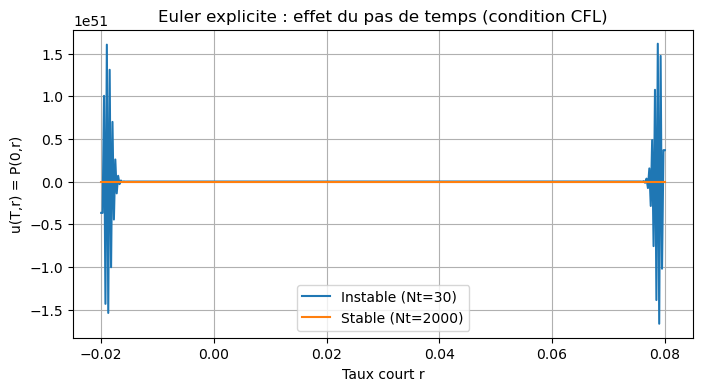

In [87]:
# ============================================================
# Comparaison profils finaux (u(T,r) = P(0,r))
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(r_grid, U_bad[-1, :], label=f"Instable (Nt={Nt_bad})")
plt.plot(r_grid, U_good[-1, :], label=f"Stable (Nt={Nt_good})")

plt.xlabel("Taux court r")
plt.ylabel("u(T,r) = P(0,r)")
plt.title("Euler explicite : effet du pas de temps (condition CFL)")
plt.legend()
plt.show()

## 4.9 Visualisation 3D en $(\tau,r)$ : Euler explicite stable vs instable

Pour illustrer visuellement la stabilité conditionnelle d’Euler explicite, on trace la surface :

$$
(\tau,r) \longmapsto u(\tau,r),
$$

dans deux cas :

- un pas de temps **compatible** avec la condition CFL (surface régulière),
- un pas de temps **trop grand** (oscillations / explosion).

On travaille ici directement en variable $\tau$ (temps restant), car le solveur explicite calcule $u(\tau,r)$.

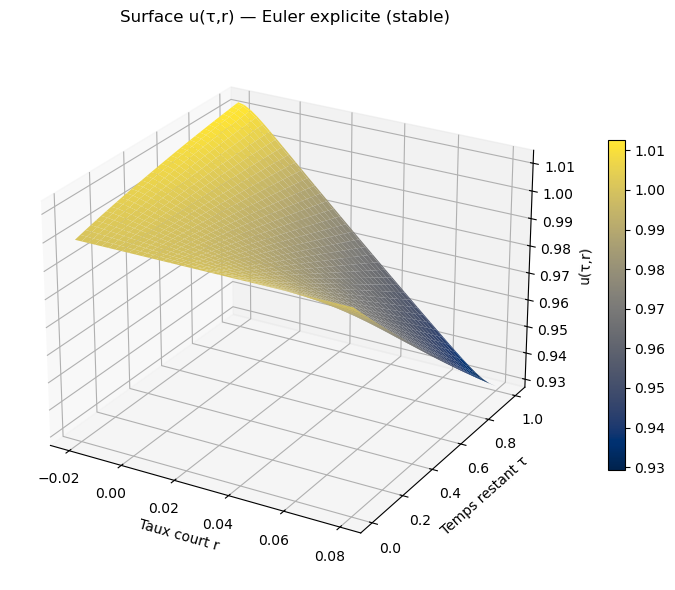

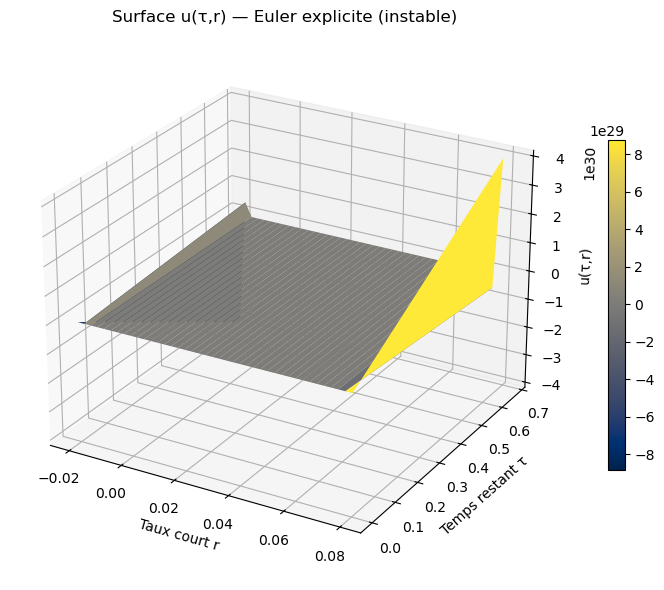

In [88]:
# ============================================================
# Surface (tau, r) -> u(tau,r) pour Euler explicite : stable vs instable
# ============================================================

def plot_surface_u_tau(tau_grid, r_grid, U, title, cmap="cividis",
                       sub_t=slice(None, None, 20),
                       sub_r=slice(None, None, 10),
                       elev=25, azim=-60,
                       zlim=None,
                       savepath=None,
                       clean=True):
    """
    Trace la surface 3D (tau, r) -> u(tau, r) (solution du solveur en tau).

    Paramètres :
      - sub_t, sub_r : sous-échantillonnage (lisibilité)
      - clean : remplace inf/nan pour éviter des crash de rendu
      - savepath : si non None, sauvegarde la figure (png, etc.)
    """
    tau = np.asarray(tau_grid, dtype=float)[sub_t]
    r = np.asarray(r_grid, dtype=float)[sub_r]
    Z = np.asarray(U, dtype=float)[sub_t, :][:, sub_r]

    if clean:
        Z = np.nan_to_num(Z, nan=np.nan, posinf=np.nan, neginf=np.nan)

    TAU, R = np.meshgrid(tau, r, indexing="ij")

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        R, TAU, Z,
        cmap=cmap,
        linewidth=0,
        antialiased=True
    )

    ax.set_title(title)
    ax.set_xlabel("Taux court r")
    ax.set_ylabel("Temps restant τ")
    ax.set_zlabel("u(τ,r)")
    ax.view_init(elev=elev, azim=azim)

    if zlim is not None:
        ax.set_zlim(*zlim)

    fig.colorbar(surf, shrink=0.6)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300)

    plt.show()
    plt.close(fig)


# ------------------------------------------------------------
# Cas stable
# ------------------------------------------------------------

plot_surface_u_tau(
    tau_grid=tau_good,
    r_grid=r_grid,
    U=U_good,
    title="Surface u(τ,r) — Euler explicite (stable)",
    cmap="cividis",
    savepath="fig_explicit_good.png",
    clean=True
)

# ------------------------------------------------------------
# Cas instable
# ------------------------------------------------------------

plot_surface_u_tau(
    tau_grid=tau_bad,
    r_grid=r_grid,
    U=U_bad,
    title="Surface u(τ,r) — Euler explicite (instable)",
    cmap="cividis",
    savepath="fig_explicit_bad.png",
    clean=True
)

## 4.9 Tests de cohérence (propriétés économiques et numériques)

Au-delà de l’erreur par rapport à la solution analytique, une solution numérique crédible doit respecter plusieurs propriétés :

- **Positivité** : un prix obligataire doit rester strictement positif.
- **Monotonie en $r$** : à maturité fixée, $r \mapsto P(0,r)$ doit être décroissante.
- **Conditions aux limites** : cohérence avec la condition de Neumann imposée numériquement.
- **Condition terminale** : $P(T,r)=1$ (au temps de maturité).

Ces tests permettent de détecter rapidement une instabilité ou une erreur d’implémentation.

[Positivité] min P(0,r) = 9.295744e-01 -> OK
[Monotonie] P(0,r) décroissant en r -> WARN/FAIL
  indices où diff>tol (premiers) : [396 397 398]
  exemple r[j], P[j], P[j+1] : 0.079 0.9295743678131307 0.9295745650712758
[Neumann] max|U(τ,r0)-U(τ,r1)|     = 0.000e+00
[Neumann] max|U(τ,rM)-U(τ,rM-1)|   = 0.000e+00
[Terminal] max|P(T,r)-1| = 0.000e+00
[Erreur] ||e||_inf à t=0 = 5.135e-03
[Erreur] RMSE à t=0      = 9.983e-04


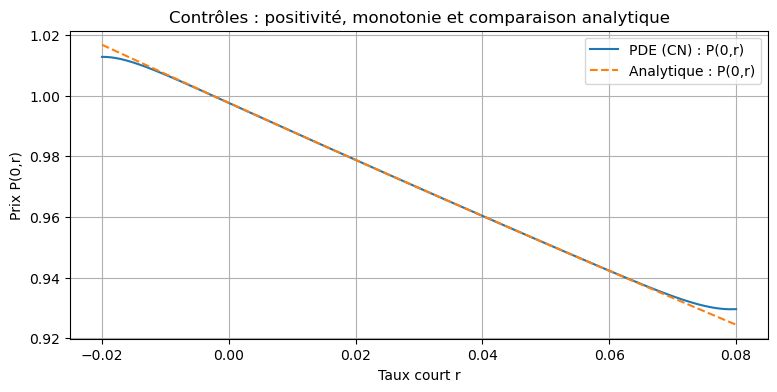

In [89]:
# ============================================================
# Tests de cohérence (sur la solution Crank–Nicolson)
# ============================================================

# Prix à t = 0 (au temps initial)
P0_num = P_c[0, :]
P0_ana = P_ana_c[0, :]

# Prix à t = T (maturité) : doit être proche de 1
PT_num = P_c[-1, :]

# ------------------------------------------------------------
# 1) Positivité
# ------------------------------------------------------------
minP = np.min(P0_num)
print(f"[Positivité] min P(0,r) = {minP:.6e} -> {'OK' if minP > 0 else 'FAIL'}")

# ------------------------------------------------------------
# 2) Monotonie : P(0,r) décroissant en r
# ------------------------------------------------------------
dP = np.diff(P0_num)
tol = 1e-10  # tolérance pour éviter les faux warnings dus au bruit numérique
mono_ok = np.all(dP <= tol)
print(f"[Monotonie] P(0,r) décroissant en r -> {'OK' if mono_ok else 'WARN/FAIL'}")

if not mono_ok:
    idx = np.where(dP > tol)[0]
    print("  indices où diff>tol (premiers) :", idx[:10])
    j = idx[0]
    print("  exemple r[j], P[j], P[j+1] :", r_grid[j], P0_num[j], P0_num[j+1])

# ------------------------------------------------------------
# 3) Conditions aux limites de Neumann (vérif sur U en tau)
# ------------------------------------------------------------
neumann_left = np.max(np.abs(U_c[:, 0] - U_c[:, 1]))
neumann_right = np.max(np.abs(U_c[:, -1] - U_c[:, -2]))
print(f"[Neumann] max|U(τ,r0)-U(τ,r1)|     = {neumann_left:.3e}")
print(f"[Neumann] max|U(τ,rM)-U(τ,rM-1)|   = {neumann_right:.3e}")

# ------------------------------------------------------------
# 4) Condition terminale : P(T,r)=1
# ------------------------------------------------------------
term_err = np.max(np.abs(PT_num - 1.0))
print(f"[Terminal] max|P(T,r)-1| = {term_err:.3e}")

# ------------------------------------------------------------
# 5) Erreur vs analytique à t=0
# ------------------------------------------------------------
print(f"[Erreur] ||e||_inf à t=0 = {linf_error(P0_num, P0_ana):.3e}")
print(f"[Erreur] RMSE à t=0      = {l2_error(P0_num, P0_ana):.3e}")

# ------------------------------------------------------------
# 6) Diagnostic visuel
# ------------------------------------------------------------
plt.figure(figsize=(9, 4))
plt.plot(r_grid, P0_num, label="PDE (CN) : P(0,r)")
plt.plot(r_grid, P0_ana, "--", label="Analytique : P(0,r)")
plt.title("Contrôles : positivité, monotonie et comparaison analytique")
plt.xlabel("Taux court r")
plt.ylabel("Prix P(0,r)")
plt.legend()
plt.show()

## 4.10 Validation probabiliste (Feynman–Kac) par Monte Carlo

L’EDP de pricing est équivalente à une représentation probabiliste :

$$
P(0,r_0)
=
\mathbb{E}^{\mathbb{Q}}\!\left[
\exp\!\left(-\int_0^T r_s ds\right)
\right].
$$

On peut donc valider numériquement le solveur EDP en comparant :

- la solution analytique (benchmark),
- la solution PDE (Crank–Nicolson),
- une estimation Monte Carlo (Euler–Maruyama + somme de Riemann).

⚠️ L’erreur Monte Carlo combine :
- une erreur statistique en $O(1/\sqrt{M})$,
- une erreur de discrétisation temporelle en $O(\Delta t)$.

=== Validation Feynman–Kac : comparaison P(0,r_init) ===
r_init = 0.050000, T = 1.0
Analytique           : 0.9512441430
PDE (Crank–Nicolson) : 0.9512454405
Monte Carlo          : 0.9512352963  (SE=3.76e-05, IC95%=[0.9511615802, 0.9513090124])
MC Δt = 5.000e-04


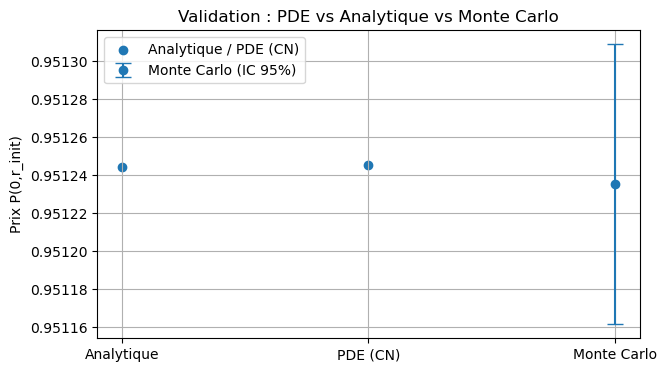

In [90]:
# ============================================================
# Monte Carlo : validation Feynman–Kac (prix du zéro-coupon)
# ============================================================

def vasicek_mc_zcb_price(a, b, sigma, r_init, T, Nt_mc=2000, M=20000, seed=1234):
    """
    Estime P(0,r_init) = E[ exp(-∫_0^T r_s ds) ] par Monte Carlo
    en simulant r_t par Euler–Maruyama et en approchant l'intégrale
    par une somme de Riemann.

    Retour :
      mean : estimateur MC
      se   : standard error
      ci95 : intervalle de confiance 95%
      dt   : pas de temps MC
    """
    rng = np.random.default_rng(seed)
    dt = T / Nt_mc
    sqrt_dt = np.sqrt(dt)

    r = np.full(M, r_init, dtype=float)
    integral = np.zeros(M, dtype=float)

    for _ in range(Nt_mc):
        integral += r * dt
        z = rng.standard_normal(M)
        r = r + a * (b - r) * dt + sigma * sqrt_dt * z

    disc = np.exp(-integral)
    mean = float(disc.mean())
    std = float(disc.std(ddof=1))
    se = std / np.sqrt(M)
    ci95 = (mean - 1.96 * se, mean + 1.96 * se)
    return mean, se, ci95, dt


# -----------------------------
# Choix du taux initial
# -----------------------------
r_init = float(b)

if not (r_grid.min() <= r_init <= r_grid.max()):
    raise ValueError(
        f"r_init={r_init} est hors de la grille [{r_grid.min()}, {r_grid.max()}]. "
        "Ajuste r_init ou élargis [r_min, r_max]."
    )

# Prix PDE (CN) à t=0, interpolé sur la grille en r
P0_pde = np.interp(r_init, r_grid, P_c[0, :])

# Prix analytique exact (sans interpolation)
P0_ana = float(P_analytic(0.0, r_init, T, a, b, sigma))

# Monte Carlo
P0_mc, se_mc, ci_mc, dt_mc = vasicek_mc_zcb_price(
    a, b, sigma, r_init, T,
    Nt_mc=2000, M=20000, seed=42
)

print("=== Validation Feynman–Kac : comparaison P(0,r_init) ===")
print(f"r_init = {r_init:.6f}, T = {T}")
print(f"Analytique           : {P0_ana:.10f}")
print(f"PDE (Crank–Nicolson) : {P0_pde:.10f}")
print(f"Monte Carlo          : {P0_mc:.10f}  (SE={se_mc:.2e}, IC95%=[{ci_mc[0]:.10f}, {ci_mc[1]:.10f}])")
print(f"MC Δt = {dt_mc:.3e}")


# -----------------------------
# Graphe : comparaisons + IC MC
# -----------------------------
plt.figure(figsize=(7, 4))
plt.scatter([0, 1], [P0_ana, P0_pde], label="Analytique / PDE (CN)")
plt.errorbar([2], [P0_mc], yerr=[1.96 * se_mc], fmt="o", capsize=6, label="Monte Carlo (IC 95%)")
plt.xticks([0, 1, 2], ["Analytique", "PDE (CN)", "Monte Carlo"])
plt.ylabel("Prix P(0,r_init)")
plt.title("Validation : PDE vs Analytique vs Monte Carlo")
plt.legend()
plt.show()

La validation Monte Carlo est effectuée pour un taux initial donné $r_0$.
Il serait possible de répéter l'expérience pour plusieurs valeurs de $r_0$,
mais cela augmenterait fortement le coût de calcul sans apporter d'information
supplémentaire sur la cohérence globale du solveur.

# 5. Convergence — temps et espace

L’objectif est de vérifier expérimentalement les ordres de convergence des schémas numériques
en comparant au benchmark analytique.

---

## 5.1 Mesure d’erreur

On se place à $t=0$ (temps initial) et on compare :

$$
e(r_i) = P_{\text{num}}(0,r_i) - P_{\text{ana}}(0,r_i).
$$

On mesure l’erreur globale en norme $L^\infty$ discrète :

$$
\|e\|_\infty = \max_{0 \le i \le M} |e(r_i)|.
$$

---

## 5.2 Ordres attendus

- En espace, les différences finies centrées sont d’ordre 2 :
  $$
  \|e\|_\infty = O(\Delta r^2).
  $$

- En temps :
  - Euler implicite est d’ordre 1 :
    $$
    \|e\|_\infty = O(\Delta\tau).
    $$
  - Crank–Nicolson est d’ordre 2 :
    $$
    \|e\|_\infty = O(\Delta\tau^2).
    $$

En pratique, l’erreur totale combine erreur spatiale et erreur temporelle.
C’est pourquoi on étudie séparément :

- convergence en temps : on varie $N_t$ à maillage spatial fixé fin,
- convergence en espace : on varie $M$ à pas de temps fixé très fin.

---

## 5.3 Protocole expérimental

1. **Convergence en temps**  
   On fixe un maillage spatial fin (grand $M$) et on fait varier $N_t$.
   On trace ensuite $\log(\|e\|_\infty)$ en fonction de $\log(\Delta\tau)$.

2. **Convergence en espace**  
   On fixe un pas de temps très fin (grand $N_t$) et on fait varier $M$.
   On trace ensuite $\log(\|e\|_\infty)$ en fonction de $\log(\Delta r)$.

Dans les deux cas, la pente de la droite en échelle log–log fournit une estimation
de l’ordre de convergence observé.

In [91]:
# ============================================================
# Tests de convergence : erreurs à t=0 en norme L_infty
# Rappel : P(0,r) = u(T,r)  => on lit directement U[-1, :]
# ============================================================

def time_convergence_test(r_grid, Nt_list, a, b, sigma, T):
    """
    Convergence en temps :
    - r_grid fixé (donc Δr fixé),
    - on varie Nt (donc Δτ),
    - on mesure ||e||_inf sur P(0,r).

    Retour :
      dtau_list, err_CN_list, err_EI_list
    """
    r_grid = np.asarray(r_grid, dtype=float)
    P0_ana = P_analytic(0.0, r_grid, T, a, b, sigma)  # uniquement t=0

    dtau_list, errs_cn, errs_ei = [], [], []

    for Nt in Nt_list:
        dtau = T / Nt
        dtau_list.append(dtau)

        # Crank–Nicolson : U[-1,:] = u(T,r) = P(0,r)
        _, U_cn = solve_pde_crank_nicolson(T, r_grid, Nt, a, b, sigma)
        P0_cn = U_cn[-1, :]
        errs_cn.append(linf_error(P0_cn, P0_ana))

        # Euler implicite
        _, U_ei = solve_pde_euler_implicit(T, r_grid, Nt, a, b, sigma)
        P0_ei = U_ei[-1, :]
        errs_ei.append(linf_error(P0_ei, P0_ana))

    return np.array(dtau_list), np.array(errs_cn), np.array(errs_ei)


def space_convergence_test(r_min, r_max, M_list, Nt_fixed, a, b, sigma, T):
    """
    Convergence en espace :
    - Nt fixé (Δτ très fin),
    - on varie M (donc Δr),
    - on mesure ||e||_inf sur P(0,r).

    Retour :
      dr_list, err_CN_list, err_EI_list
    """
    dr_list, errs_cn, errs_ei = [], [], []

    for M in M_list:
        r_grid_local = np.linspace(r_min, r_max, M + 1)
        dr = r_grid_local[1] - r_grid_local[0]
        dr_list.append(dr)

        P0_ana = P_analytic(0.0, r_grid_local, T, a, b, sigma)

        # Crank–Nicolson
        _, U_cn = solve_pde_crank_nicolson(T, r_grid_local, Nt_fixed, a, b, sigma)
        P0_cn = U_cn[-1, :]
        errs_cn.append(linf_error(P0_cn, P0_ana))

        # Euler implicite
        _, U_ei = solve_pde_euler_implicit(T, r_grid_local, Nt_fixed, a, b, sigma)
        P0_ei = U_ei[-1, :]
        errs_ei.append(linf_error(P0_ei, P0_ana))

    return np.array(dr_list), np.array(errs_cn), np.array(errs_ei)

## 5.4 Convergence en temps

On fixe la grille spatiale (donc $\Delta r$ fixé) et l’on fait varier le pas temporel
$\Delta\tau = T/N_t$.

On trace $\|e\|_\infty$ en fonction de $\Delta\tau$ en échelle log–log.
La pente observée fournit une estimation de l’ordre :

- Euler implicite : ordre attendu $\approx 1$,
- Crank–Nicolson : ordre attendu $\approx 2$.

Ordre observé (temps) — Crank–Nicolson : p ≈ 0.46 (attendu ~2)
Ordre observé (temps) — Euler implicite : p ≈ 0.56 (attendu ~1)


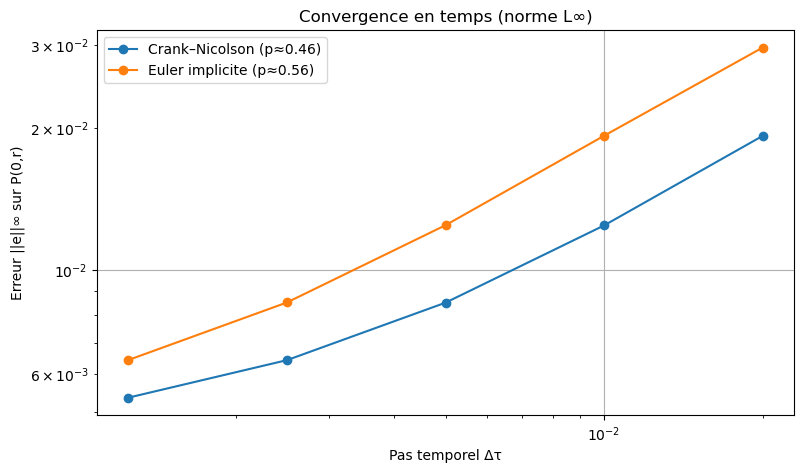

In [92]:
# ============================================================
# Convergence en temps : log–log + estimation d'ordre
# ============================================================

Nt_list = [50, 100, 200, 400, 800]
dtau, err_cn_t, err_ei_t = time_convergence_test(r_grid, Nt_list, a, b, sigma, T)

# Estimation d'ordre par régression linéaire sur log(err) ~ p log(dtau) + c
p_cn, c_cn = np.polyfit(np.log(dtau), np.log(err_cn_t), 1)
p_ei, c_ei = np.polyfit(np.log(dtau), np.log(err_ei_t), 1)

print(f"Ordre observé (temps) — Crank–Nicolson : p ≈ {p_cn:.2f} (attendu ~2)")
print(f"Ordre observé (temps) — Euler implicite : p ≈ {p_ei:.2f} (attendu ~1)")

plt.figure()
plt.loglog(dtau, err_cn_t, "o-", label=f"Crank–Nicolson (p≈{p_cn:.2f})")
plt.loglog(dtau, err_ei_t, "o-", label=f"Euler implicite (p≈{p_ei:.2f})")
plt.xlabel("Pas temporel Δτ")
plt.ylabel("Erreur ||e||∞ sur P(0,r)")
plt.title("Convergence en temps (norme L∞)")
plt.legend()
plt.show()

## 5.5 Convergence en espace

On fixe un pas de temps très fin (grand $N_t$) afin que l’erreur temporelle soit négligeable,
puis on fait varier le pas spatial $\Delta r$ via le nombre de points $M$.

On trace $\|e\|_\infty$ en fonction de $\Delta r$ en échelle log–log.
Avec des différences finies centrées, l’ordre attendu est :

$$
\|e\|_\infty = O(\Delta r^2).
$$

Ordre observé (espace) — Crank–Nicolson : p ≈ 0.00 (attendu ~2)
Ordre observé (espace) — Euler implicite : p ≈ -0.05 (attendu ~2)


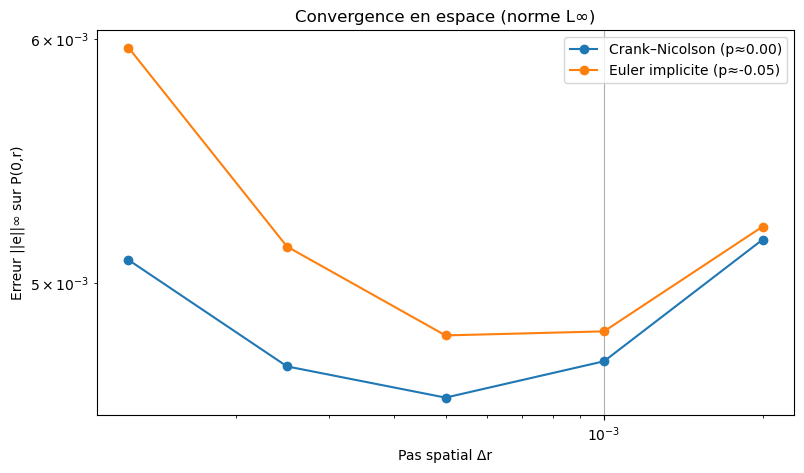

In [93]:
# ============================================================
# Convergence en espace : log–log + estimation d'ordre
# ============================================================

M_list = [50, 100, 200, 400, 800]
Nt_fixed = 2000  # Δτ très fin pour isoler l'erreur spatiale

dr, err_cn_s, err_ei_s = space_convergence_test(r_min, r_max, M_list, Nt_fixed, a, b, sigma, T)

# Estimation d'ordre (sur log–log)
p_cn_s, _ = np.polyfit(np.log(dr), np.log(err_cn_s), 1)
p_ei_s, _ = np.polyfit(np.log(dr), np.log(err_ei_s), 1)

print(f"Ordre observé (espace) — Crank–Nicolson : p ≈ {p_cn_s:.2f} (attendu ~2)")
print(f"Ordre observé (espace) — Euler implicite : p ≈ {p_ei_s:.2f} (attendu ~2)")

plt.figure()
plt.loglog(dr, err_cn_s, "o-", label=f"Crank–Nicolson (p≈{p_cn_s:.2f})")
plt.loglog(dr, err_ei_s, "o-", label=f"Euler implicite (p≈{p_ei_s:.2f})")
plt.xlabel("Pas spatial Δr")
plt.ylabel("Erreur ||e||∞ sur P(0,r)")
plt.title("Convergence en espace (norme L∞)")
plt.legend()
plt.show()

Lorsque $\Delta r$ devient très petit, on peut observer une saturation de l'erreur
(si elle apparaît). Cela s’explique par la combinaison :
- de l’erreur temporelle résiduelle,
- des effets de troncature (bords),
- et des limites numériques (arrondis).

# 6. Calibration sur courbe AAA (BCE)

L’objectif est de calibrer les paramètres du modèle de Vasicek afin de reproduire au mieux une **courbe de taux spot de marché** (courbe “AAA” publiée par la BCE).

Nous considérons deux variantes :

1. **Calibration libre** : estimation simultanée $(a,b,\sigma,r_0)$.
2. **Calibration avec $\sigma$ fixé** : estimation de $(a,b,r_0)$ en imposant $\sigma=\sigma_{\text{fixe}}$
   (utile lorsque $\sigma$ est mal identifié à partir d’une seule courbe).

---

## 6.1 Données de marché (snapshot BCE)

On construit une courbe instantanée à partir de l’API SDMX de la BCE :

$$
\{(T_i, R_{\mathrm{mkt}}(0,T_i))\}_{i=1}^n,
$$

où $T_i$ est une maturité (en années) et $R_{\mathrm{mkt}}(0,T_i)$ est un taux spot (en décimal).

**Reproductibilité :**
- le notebook est reproductible au sens où il s’exécute sans fichiers externes ;
- les résultats dépendent cependant de la date de marché (la courbe évolue dans le temps).

Pour auditabilité, on peut **sauvegarder un snapshot** (CSV) des données récupérées.

---

## 6.2 Quantité calibrée : taux spot

Le modèle de Vasicek fournit un prix zéro-coupon analytique à $t=0$ :

$$
P_{\mathrm{mod}}(0,T)
=
A(T)\,\exp\!\big(-B(T)\,r_0\big),
$$

d’où le taux spot modèle :

$$
R_{\mathrm{mod}}(0,T)
=
-\frac{1}{T}\ln P_{\mathrm{mod}}(0,T).
$$

---

## 6.3 Problème de moindres carrés pondéré

On résout :

$$
\min_{\theta}
\sum_i w_i\left(R_{\mathrm{mod}}(0,T_i;\theta) - R_{\mathrm{mkt}}(0,T_i)\right)^2,
$$

avec :

- $\theta = (a,b,\sigma,r_0)$ (calibration libre),
- $\theta = (a,b,r_0)$ si $\sigma$ est fixé.

Dans la suite, on utilise typiquement des poids :

$$
w_i=\frac{1}{T_i},
$$

afin de privilégier l’ajustement des maturités courtes et de limiter l’influence des très longues maturités.

## Données de marché : récupération automatique via la BCE (ECB / SDMX)

Afin que le notebook soit **reproductible** et ne dépende pas de fichiers locaux, on récupère à chaque exécution une courbe de taux “AAA” publiée par la BCE :

**Euro area yield curve — AAA-rated government bonds — Spot rates**

via l’API **SDMX** (ECB Data Portal, dataset `YC`).

---

### Maturités interrogées

On interroge un ensemble standard de maturités (par exemple) :

- 3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 15Y, 20Y, 30Y.

Chaque maturité correspond à une série temporelle de taux spot.

---

### Règles de construction de la courbe “snapshot”

Pour construire une courbe cohérente à partir de séries éventuellement incomplètes :

1. Pour chaque maturité, on récupère la **dernière observation disponible**.
2. Si une maturité est indisponible (série manquante / erreur / pas de donnée récente), elle est **ignorée proprement**.
3. Si les dates des “dernières observations” diffèrent selon les maturités (jours fériés / publication asynchrone), on conserve la date la plus fréquente (le **mode**) afin d’obtenir une courbe la plus homogène possible.

On obtient ainsi une courbe instantanée $ T \mapsto R_{\mathrm{mkt}}(0,T) $ associée à une date de marché unique.

---

### Format final utilisé dans la calibration

Le code produit :

- une table `df_mkt` contenant au moins : maturité, date, taux spot,
- deux vecteurs triés par maturité croissante :
  - `T_mkt` : maturités en années,
  - `R_mkt` : taux spot en **décimal** (ex. $0.021 = 2.1\%$).

---

### Option : sauvegarde d’un snapshot

Pour auditabilité (et pour rejouer exactement le même marché plus tard), on peut sauvegarder le snapshot utilisé au format CSV, par exemple `market_curve_ecb.csv`.

### Implémentation : requêtes SDMX (format CSV) et construction du snapshot

On interroge l’API SDMX de la BCE via l’endpoint :

$$
\texttt{GET } /service/data/YC/\{key\}\;?\;\texttt{format=csvdata\&lastNObservations=1}
$$

où `key` désigne une série “spot rate” AAA à maturité fixée.

**Sorties produites par le code :**
- `df_mkt` : table du snapshot (maturité, date, taux),
- `T_mkt` : maturités en années,
- `R_mkt` : taux spots en décimal.

**Note sur la reproductibilité :**  
le notebook est reproductible au sens “il s’exécute sans fichiers locaux”, mais les résultats numériques dépendent de la date de marché.  
On peut donc sauvegarder un CSV de snapshot pour figer exactement les données utilisées.

In [94]:
import io
import requests

# -----------------------------
# ECB SDMX fetch helpers (Yield Curve - YC)
# -----------------------------
ECB_BASE = "https://data-api.ecb.europa.eu/service/data"

# Série AAA spot rates (dataset YC). Les "series keys" sur le portail apparaissent souvent
# sous la forme "YC.B.U2....". L'API attend /YC/{key} => on accepte les deux formats.
AAA_SPOT_KEYS = {
    "3M":  "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3M",
    "6M":  "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M",
    "1Y":  "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y",
    "2Y":  "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y",
    "3Y":  "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y",
    "5Y":  "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y",
    "7Y":  "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_7Y",
    "10Y": "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y",
    "15Y": "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_15Y",
    "20Y": "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_20Y",
    "30Y": "B.U2.EUR.4F.G_N_A.SV_C_YM.SR_30Y",
}

def maturity_to_years(m):
    if m.endswith("M"):
        return float(m[:-1]) / 12.0
    if m.endswith("Y"):
        return float(m[:-1])
    raise ValueError(f"Maturité inconnue: {m}")

def _normalize_yc_key(key: str) -> str:
    """
    Accepte des clés du type 'YC.B....' (copiées depuis le portail)
    ou 'B....' (dimension key), et renvoie le format attendu par /YC/{key}.
    """
    key = str(key).strip()
    if key.startswith("YC."):
        return key[len("YC."):]
    return key

def fetch_last_observation_yc(session: requests.Session, key: str, timeout=30):
    """
    Récupère la dernière observation (date, valeur) d'une série YC via CSV SDMX :

        GET /service/data/YC/{key}?format=csvdata&lastNObservations=1

    Retour :
      (date_str, value_percent)

    Remarque : sur le portail ECB, les valeurs sont en 'Percent per annum'.
    """
    key = _normalize_yc_key(key)
    url = f"{ECB_BASE}/YC/{key}"
    params = {"format": "csvdata", "lastNObservations": 1}

    r = session.get(
        url,
        params=params,
        timeout=timeout,
        headers={"User-Agent": "vasicek-notebook/1.0"},
    )
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code} on {r.url}\n{r.text[:200]}")

    df = pd.read_csv(io.StringIO(r.text))

    # Colonnes SDMX CSV standard : TIME_PERIOD, OBS_VALUE
    if ("TIME_PERIOD" not in df.columns) or ("OBS_VALUE" not in df.columns):
        raise RuntimeError(f"Colonnes inattendues ECB pour {key}: {list(df.columns)}")

    df = df.dropna(subset=["TIME_PERIOD", "OBS_VALUE"])
    if df.empty:
        raise RuntimeError(f"Aucune donnée reçue pour {key}")

    row = df.iloc[-1]
    return str(row["TIME_PERIOD"]), float(row["OBS_VALUE"])

def build_market_curve(keys_dict, min_points=5):
    """
    Construit une courbe snapshot (maturité -> dernier taux spot).

    - Ignore proprement les séries indisponibles
    - Conserve une date cohérente via la date la plus fréquente (mode)
    - Convertit en décimal : R_dec = R_pct / 100
    """
    rows = []

    with requests.Session() as session:
        for mat, key in keys_dict.items():
            try:
                d, v_pct = fetch_last_observation_yc(session, key)
                T = maturity_to_years(mat)
                rows.append((mat, T, d, v_pct))
            except Exception as e:
                print(f"[WARN] Skip {mat} ({key}) : {e}")

    if len(rows) < min_points:
        raise RuntimeError("Trop peu de points récupérés. Vérifie connectivité et clés ECB.")

    df = pd.DataFrame(rows, columns=["maturity", "T_years", "date", "R_pct"])

    # Date la plus fréquente pour avoir une courbe cohérente
    mode_date = df["date"].mode().iloc[0]
    df = df[df["date"] == mode_date].copy()

    df.sort_values("T_years", inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Conversion % -> décimal
    df["R_dec"] = df["R_pct"] / 100.0
    return df, mode_date

# --- Exécution ---
df_mkt, date_used = build_market_curve(AAA_SPOT_KEYS)

print(f"✅ Courbe ECB AAA spot récupérée — date utilisée: {date_used}")
display(df_mkt[["maturity", "T_years", "R_pct"]])

# (optionnel) sauvegarde snapshot pour auditabilité / reproductibilité "fixée"
SAVE_SNAPSHOT = True
if SAVE_SNAPSHOT:
    df_mkt.to_csv("market_curve_ecb.csv", index=False)
    print("📌 Snapshot sauvegardé : market_curve_ecb.csv")

# Vecteurs pour la calibration
T_mkt = df_mkt["T_years"].to_numpy()
R_mkt = df_mkt["R_dec"].to_numpy()

✅ Courbe ECB AAA spot récupérée — date utilisée: 2026-03-04


,maturity,T_years,R_pct
0,3M,0.25,2.010865
1,6M,0.50,2.018096
2,1Y,1.00,2.038606
3,2Y,2.00,2.098893
4,3Y,3.00,2.177170
5,5Y,5.00,2.361027
6,7Y,7.00,2.553040
7,10Y,10.00,2.817276
8,15Y,15.00,3.146208
9,20Y,20.00,3.337260


📌 Snapshot sauvegardé : market_curve_ecb.csv


## Calibration libre $(a,b,\sigma,r_0)$ par moindres carrés

On observe une courbe de taux spot de marché :

$$
\left\{(T_i,\,R_{\mathrm{mkt}}(0,T_i))\right\}_{i=1}^n.
$$

Le modèle de Vasicek donne un prix zéro-coupon analytique à $t=0$ :

$$
P_{\mathrm{mod}}(0,T)=A(T)\exp\!\big(-B(T)\,r_0\big),
$$

et donc un taux spot modèle :

$$
R_{\mathrm{mod}}(0,T)=-\frac{1}{T}\ln P_{\mathrm{mod}}(0,T).
$$

La calibration consiste à résoudre :

$$
\min_{a,b,\sigma,r_0}\;\sum_i w_i\left(R_{\mathrm{mod}}(0,T_i)-R_{\mathrm{mkt}}(0,T_i)\right)^2.
$$

Choix des poids : on privilégie le court terme via

$$
w_i=\frac{1}{T_i},
$$

ce qui reflète l’importance pratique des maturités courtes et limite l’influence des très longues maturités.

✅ Calibration libre (ECB AAA spot)
  date utilisée : 2026-03-04
  a     = 0.056679
  b     = 5.162394%
  sigma = 0.000020%
  r0    = 1.974402%
  RMSE  = 8.38 bp
  coût  = 3.65343e-07 | status=1 | eval=20


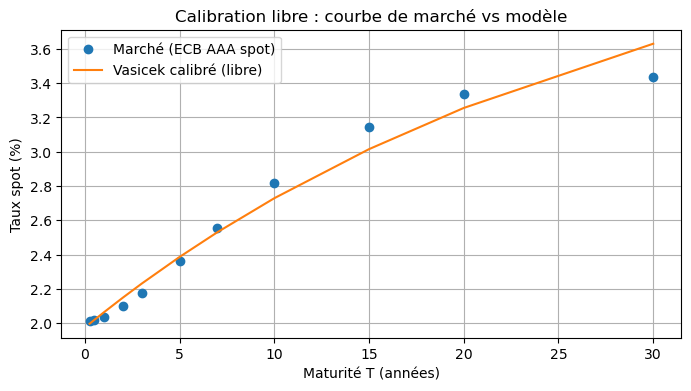

In [95]:
# ============================================================
# Calibration libre : (a, b, sigma, r0)
# ============================================================

T_mkt = np.asarray(T_mkt, dtype=float)
R_mkt = np.asarray(R_mkt, dtype=float)

# Poids : plus de poids sur le court terme
w = 1.0 / np.maximum(T_mkt, 1e-6)

def R0T_model(T, a, b, sigma, r0):
    """
    T en années (t=0), sortie en décimal.
    Remarque : ici tau = T puisque t=0.
    """
    T = np.asarray(T, dtype=float)
    P = A_vasicek(T, a, b, sigma) * np.exp(-B_vasicek(T, a) * r0)
    return -np.log(P) / np.maximum(T, 1e-12)

def residuals_free(x, T, R_mkt, w):
    a, b, sigma, r0 = x
    R_mod = R0T_model(T, a, b, sigma, r0)
    return np.sqrt(w) * (R_mod - R_mkt)

# Initial guess (raisonnable)
x0 = np.array([
    0.10,                  # a
    float(np.median(R_mkt)),# b
    0.01,                  # sigma
    float(R_mkt[0])        # r0 ~ taux court terme
], dtype=float)

# Bornes raisonnables
lb = np.array([1e-4, -0.10, 1e-8, -0.10], dtype=float)
ub = np.array([5.0,   0.20,  0.30,  0.20], dtype=float)

res = least_squares(
    residuals_free,
    x0,
    bounds=(lb, ub),
    args=(T_mkt, R_mkt, w),
    method="trf"
)

a_hat, b_hat, sigma_hat, r0_hat = res.x

# Diagnostics simples
R_fit = R0T_model(T_mkt, a_hat, b_hat, sigma_hat, r0_hat)
rmse = np.sqrt(np.mean((R_fit - R_mkt) ** 2))
rmse_bp = 1e4 * rmse  # 1 bp = 1e-4

date_used = df_mkt["date"].iloc[0] if ("date" in df_mkt.columns and len(df_mkt) > 0) else "n/a"

print("✅ Calibration libre (ECB AAA spot)")
print(f"  date utilisée : {date_used}")
print(f"  a     = {a_hat:.6f}")
print(f"  b     = {b_hat:.6%}")
print(f"  sigma = {sigma_hat:.6%}")
print(f"  r0    = {r0_hat:.6%}")
print(f"  RMSE  = {rmse_bp:.2f} bp")
print(f"  coût  = {res.cost:.6g} | status={res.status} | eval={res.nfev}")

# Visualisation : marché vs modèle
plt.figure(figsize=(8, 4))
plt.plot(T_mkt, 100 * R_mkt, "o", label="Marché (ECB AAA spot)")
plt.plot(T_mkt, 100 * R_fit, "-", label="Vasicek calibré (libre)")
plt.xlabel("Maturité T (années)")
plt.ylabel("Taux spot (%)")
plt.title("Calibration libre : courbe de marché vs modèle")
plt.legend()
plt.show()

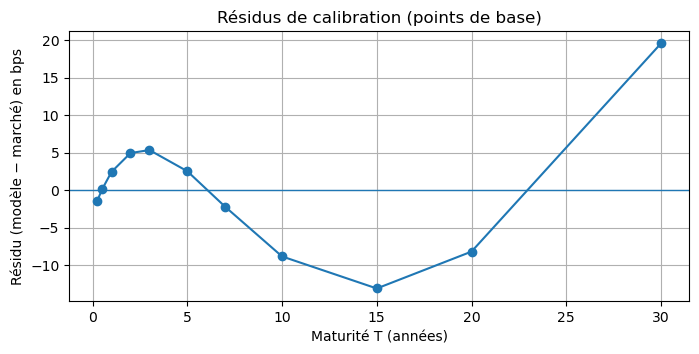

In [96]:
# ============================================================
# Diagnostics de calibration : courbe lissée + résidus (bps)
# ============================================================

T_plot = np.linspace(float(np.min(T_mkt)), float(np.max(T_mkt)), 300)

R_fit_pts   = R0T_model(T_mkt,  a_hat, b_hat, sigma_hat, r0_hat)

# Résidus en points de base
resid_bps = 1e4 * (R_fit_pts - R_mkt)

plt.figure(figsize=(8, 3.5))
plt.plot(T_mkt, resid_bps, "o-")
plt.axhline(0.0, linewidth=1)
plt.xlabel("Maturité T (années)")
plt.ylabel("Résidu (modèle − marché) en bps")
plt.title("Résidus de calibration (points de base)")
plt.show()

On observe que les résidus ne sont pas uniformes selon la maturité : le modèle de Vasicek (1 facteur) impose une structure très contrainte de la courbe de taux. Les écarts systématiques sur certaines zones de maturité reflètent une limite structurelle du modèle, plus qu’un simple défaut numérique.

## Calibration avec $\sigma$ fixé (comparaison)

Sur une seule courbe spot observée à une date donnée, l’identification simultanée de $(a,b,\sigma,r_0)$ peut être fragile, on obtenait en l'occurence $\sigma \approx 0$ :

- plusieurs triplets $(a,b,\sigma)$ peuvent produire des courbes très proches,
- la volatilité $\sigma$ est en pratique mieux identifiée par des données de dynamique (historique des taux) ou par des options de taux.

Pour étudier cette question, on effectue une calibration alternative en fixant :

$$
\sigma = \sigma_{\text{fixe}},
$$

et en calibrant seulement :

$$
(a,b,r_0).
$$

On compare ensuite :

- la qualité d’ajustement (RMSE, résidus),
- la stabilité des paramètres obtenus,
- et l’impact de l’hypothèse sur la courbe reproduite.

✅ Calibration avec sigma fixé
  date utilisée : 2026-03-04
  sigma = 3.00% (fixé)
  a     = 0.223005
  b     = 3.914938%
  r0    = 1.911744%
  RMSE  = 25.43 bp
  coût  = 3.61152e-06 | status=1 | eval=20


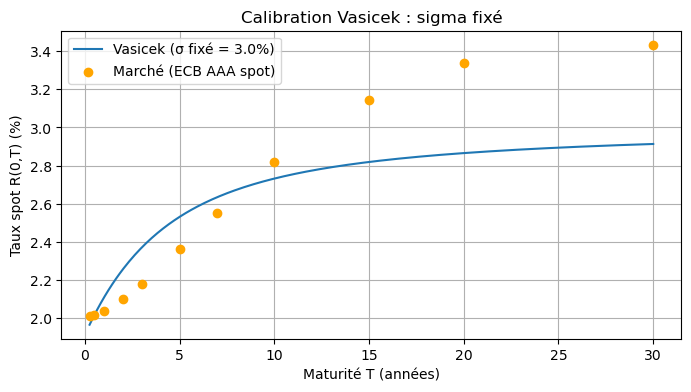

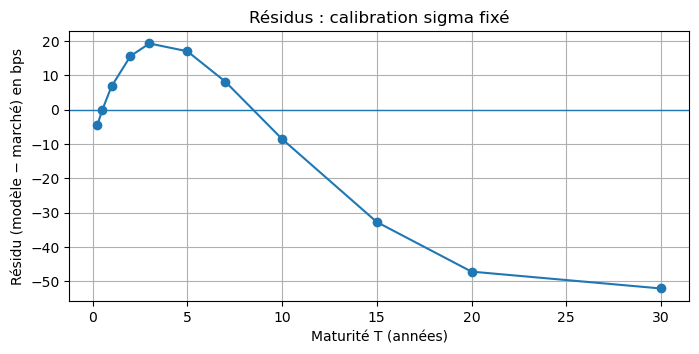

In [97]:
# ============================================================
# Calibration avec sigma fixé : (a, b, r0) avec sigma = sigma_fixed
# ============================================================

sigma_fixed = 0.03  # 3% (à discuter dans l'analyse)

w_fix = 1.0 / np.maximum(T_mkt, 1e-6)

def residuals_sigma_fixed(x, T, R_mkt, w, sigma_fixed):
    a, b, r0 = x
    R_mod = R0T_model(T, a, b, sigma_fixed, r0)
    return np.sqrt(w) * (R_mod - R_mkt)

# Initial guess cohérent
x0_fix = np.array([
    0.10,                   # a
    float(np.median(R_mkt)), # b
    float(R_mkt[0])          # r0
], dtype=float)

lb_fix = np.array([1e-4, -0.10, -0.10], dtype=float)
ub_fix = np.array([5.0,   0.20,  0.20], dtype=float)

res_fix = least_squares(
    residuals_sigma_fixed,
    x0_fix,
    bounds=(lb_fix, ub_fix),
    args=(T_mkt, R_mkt, w_fix, sigma_fixed),
    method="trf"
)

a_fix, b_fix, r0_fix = res_fix.x

# Diagnostics
R_fit_fix = R0T_model(T_mkt, a_fix, b_fix, sigma_fixed, r0_fix)
rmse_fix = np.sqrt(np.mean((R_fit_fix - R_mkt) ** 2))
rmse_fix_bp = 1e4 * rmse_fix

date_used = df_mkt["date"].iloc[0] if ("date" in df_mkt.columns and len(df_mkt) > 0) else "n/a"

print("✅ Calibration avec sigma fixé")
print(f"  date utilisée : {date_used}")
print(f"  sigma = {sigma_fixed:.2%} (fixé)")
print(f"  a     = {a_fix:.6f}")
print(f"  b     = {b_fix:.6%}")
print(f"  r0    = {r0_fix:.6%}")
print(f"  RMSE  = {rmse_fix_bp:.2f} bp")
print(f"  coût  = {res_fix.cost:.6g} | status={res_fix.status} | eval={res_fix.nfev}")

# Courbe ajustée
T_plot = np.linspace(float(np.min(T_mkt)), float(np.max(T_mkt)), 300)
R_curve_fix = R0T_model(T_plot, a_fix, b_fix, sigma_fixed, r0_fix)

plt.figure(figsize=(8, 4))
plt.plot(T_plot, 100 * R_curve_fix, label=f"Vasicek (σ fixé = {100*sigma_fixed:.1f}%)")
plt.scatter(T_mkt, 100 * R_mkt, color = "orange", label="Marché (ECB AAA spot)", zorder=3)
plt.xlabel("Maturité T (années)")
plt.ylabel("Taux spot R(0,T) (%)")
plt.title("Calibration Vasicek : sigma fixé")
plt.legend()
plt.show()

# Résidus
resid_fix_bps = 1e4 * (R_fit_fix - R_mkt)
plt.figure(figsize=(8, 3.5))
plt.plot(T_mkt, resid_fix_bps, "o-")
plt.axhline(0.0, linewidth=1)
plt.xlabel("Maturité T (années)")
plt.ylabel("Résidu (modèle − marché) en bps")
plt.title("Résidus : calibration sigma fixé")
plt.show()

=== Comparaison calibration ===
RMSE libre      : 8.38 bp
RMSE σ fixé     : 25.43 bp


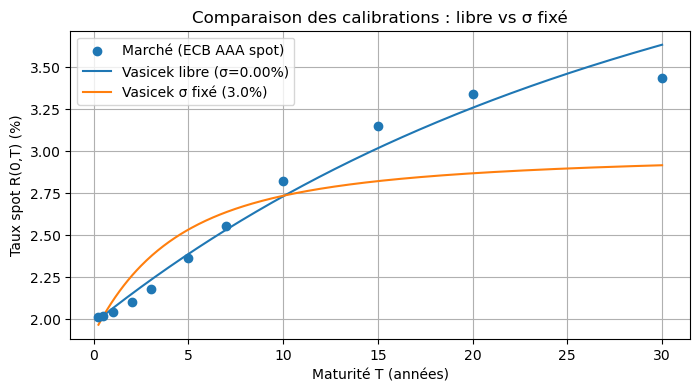

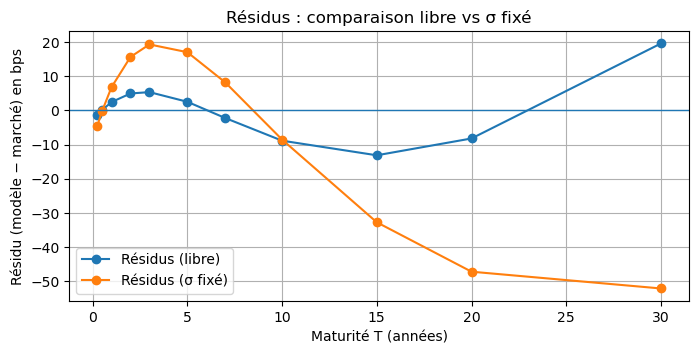

In [98]:
# ============================================================
# Comparaison : calibration libre vs sigma fixé
# ============================================================

# Courbes sur une même grille pour comparaison
T_plot = np.linspace(float(np.min(T_mkt)), float(np.max(T_mkt)), 400)

R_curve_free = R0T_model(T_plot, a_hat, b_hat, sigma_hat, r0_hat)
R_curve_fix  = R0T_model(T_plot, a_fix, b_fix, sigma_fixed, r0_fix)

R_fit_free_pts = R0T_model(T_mkt, a_hat, b_hat, sigma_hat, r0_hat)
R_fit_fix_pts  = R0T_model(T_mkt, a_fix, b_fix, sigma_fixed, r0_fix)

rmse_free_bp = 1e4 * np.sqrt(np.mean((R_fit_free_pts - R_mkt) ** 2))
rmse_fix_bp  = 1e4 * np.sqrt(np.mean((R_fit_fix_pts - R_mkt) ** 2))

print("=== Comparaison calibration ===")
print(f"RMSE libre      : {rmse_free_bp:.2f} bp")
print(f"RMSE σ fixé     : {rmse_fix_bp:.2f} bp")

plt.figure(figsize=(8, 4))
plt.scatter(T_mkt, 100 * R_mkt, label="Marché (ECB AAA spot)", zorder=3)
plt.plot(T_plot, 100 * R_curve_free, label=f"Vasicek libre (σ={100*sigma_hat:.2f}%)")
plt.plot(T_plot, 100 * R_curve_fix,  label=f"Vasicek σ fixé ({100*sigma_fixed:.1f}%)")
plt.xlabel("Maturité T (années)")
plt.ylabel("Taux spot R(0,T) (%)")
plt.title("Comparaison des calibrations : libre vs σ fixé")
plt.legend()
plt.show()

# Résidus côte à côte (bps)
resid_free_bps = 1e4 * (R_fit_free_pts - R_mkt)
resid_fix_bps  = 1e4 * (R_fit_fix_pts - R_mkt)

plt.figure(figsize=(8, 3.5))
plt.plot(T_mkt, resid_free_bps, "o-", label="Résidus (libre)")
plt.plot(T_mkt, resid_fix_bps, "o-", label="Résidus (σ fixé)")
plt.axhline(0.0, linewidth=1)
plt.xlabel("Maturité T (années)")
plt.ylabel("Résidu (modèle − marché) en bps")
plt.title("Résidus : comparaison libre vs σ fixé")
plt.legend()
plt.show()

On compare les deux calibrations :

- la calibration libre peut obtenir un meilleur ajustement (RMSE plus faible), mais au prix d’un paramètre $\sigma$ parfois instable ou peu interprétable à partir d’une seule courbe.
- la calibration avec $\sigma$ fixé est souvent plus robuste et facilite l’interprétation des paramètres $(a,b,r_0)$, mais peut dégrader l’ajustement sur certaines maturités.

Cette comparaison illustre une limite classique : une seule courbe de taux “cross-section” identifie imparfaitement la volatilité du taux court.

# 7. Analyse quantitative des paramètres (sensibilité)

L’objectif est d’étudier l’influence des paramètres du modèle de Vasicek sur la structure par terme des taux spot :

$$
R(0,T)
=
-\frac{1}{T}\ln P(0,T).
$$

On analyse séparément l’effet de :

- $b$ : niveau de long terme,
- $a$ : vitesse de rappel,
- $\sigma$ : volatilité.

Dans chaque cas :

- un paramètre est varié,
- les autres sont maintenus constants,
- on observe l’impact sur la courbe $T \mapsto R(0,T)$.

Cette analyse permet de relier directement la structure mathématique du modèle
à son interprétation économique.

## 7.1 Protocole de sensibilité

On fixe un jeu de paramètres “base” :

$$
(a,b,\sigma,r_0)=(a_{\mathrm{base}},b_{\mathrm{base}},\sigma_{\mathrm{base}},r_{0,\mathrm{base}}),
$$

puis on fait varier un paramètre à la fois afin d’observer l’effet sur :

$$
T \longmapsto R(0,T).
$$

Cette approche “one-at-a-time” permet d’interpréter qualitativement :

- comment le modèle se déforme lorsqu’on modifie un paramètre,
- quelles maturités sont les plus sensibles à chaque paramètre.

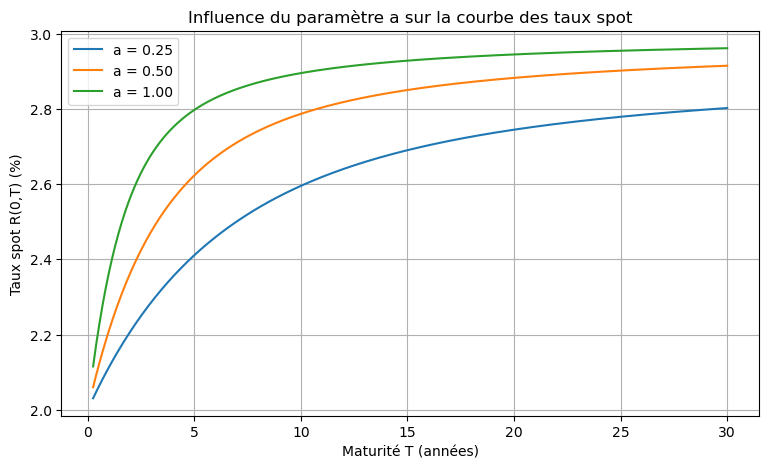

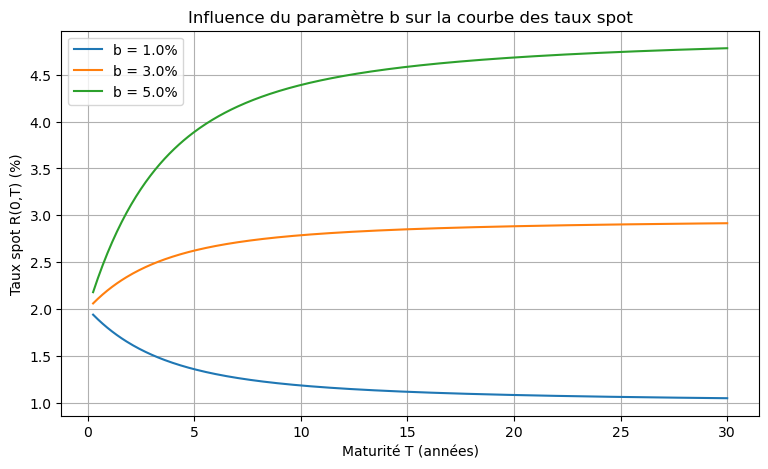

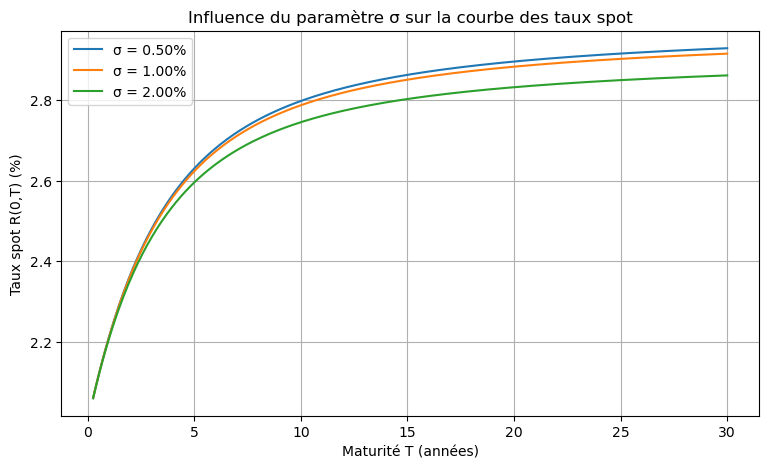

In [99]:
T_curve = np.linspace(0.25, 30.0, 400)
r0_base = 0.02
a_base, b_base, sigma_base = 0.50, 0.03, 0.01

plt.figure()
for a_ in [0.25, 0.50, 1.00]:
    plt.plot(T_curve, 100*R0T_model(T_curve, a_, b_base, sigma_base, r0_base), label=f"a = {a_:.2f}")
plt.xlabel("Maturité T (années)")
plt.ylabel("Taux spot R(0,T) (%)")
plt.title("Influence du paramètre a sur la courbe des taux spot")
plt.legend()
plt.show()

plt.figure()
for b_ in [0.01, 0.03, 0.05]:
    plt.plot(T_curve, 100*R0T_model(T_curve, a_base, b_, sigma_base, r0_base), label=f"b = {100*b_:.1f}%")
plt.xlabel("Maturité T (années)")
plt.ylabel("Taux spot R(0,T) (%)")
plt.title("Influence du paramètre b sur la courbe des taux spot")
plt.legend()
plt.show()

plt.figure()
for s_ in [0.005, 0.01, 0.02]:
    plt.plot(T_curve, 100*R0T_model(T_curve, a_base, b_base, s_, r0_base), label=f"σ = {100*s_:.2f}%")
plt.xlabel("Maturité T (années)")
plt.ylabel("Taux spot R(0,T) (%)")
plt.title("Influence du paramètre σ sur la courbe des taux spot")
plt.legend()
plt.show()

# 8. Discussion — limites du modèle

L’étude numérique et la calibration mettent en évidence plusieurs limites structurelles du modèle de Vasicek.

---

## 8.1 Taux négatifs

Le taux court suit une dynamique gaussienne :

$$
dr_t = a(b-r_t)\,dt + \sigma\,dW_t.
$$

Le processus étant normal, il peut prendre des valeurs négatives avec une probabilité non nulle.  

Bien que cela ne soit plus totalement irréaliste dans un contexte de taux bas observé depuis les années 2010, le modèle autorise également des taux très négatifs sur des horizons longs, ce qui peut devenir économiquement discutable.

---

## 8.2 Volatilité constante

Le bruit est **additif** :

$$
\sigma\,dW_t,
$$

ce qui implique une volatilité indépendante du niveau du taux.

Empiriquement, la volatilité des taux dépend souvent du niveau du taux lui-même.  
Le modèle de Vasicek ne capture pas cet effet.

---

## 8.3 Identification limitée de $\sigma$

La calibration sur une **seule courbe spot** fournit essentiellement une information “statique” (cross-section à une date donnée).

Or :

- $\sigma$ agit via des termes de convexité dans $A(T)$,
- son effet sur la courbe spot est relativement lisse,
- plusieurs couples $(a,\sigma)$ peuvent produire des courbes très proches.

C’est pourquoi la calibration libre conduit souvent à une valeur de $\sigma$ très faible ou instable.  

En pratique, $\sigma$ est plutôt calibré sur :

- des instruments optionnels (caps, swaptions),
- ou des séries temporelles du taux court.

---

## 8.4 Modèles alternatifs

Plusieurs extensions corrigent certaines limites :

- **CIR (Cox–Ingersoll–Ross)** : volatilité proportionnelle à $\sqrt{r_t}$ → garantit la positivité.
- **Hull–White** : version à paramètres dépendant du temps → permet un ajustement exact à la courbe initiale.

Ces modèles illustrent le compromis classique entre :

- simplicité analytique,
- réalisme économique,
- capacité d’ajustement.

---

# 9. Conclusion

Ce projet a permis d’analyser de manière cohérente :

- la dynamique stochastique du taux court,
- la formulation EDP via Feynman–Kac,
- la résolution numérique par différences finies,
- la validation croisée (analytique, PDE, Monte Carlo),
- la calibration sur données de marché réelles.

---

## 9.1 Enseignements numériques

- La solution analytique constitue un **benchmark robuste**.
- Euler implicite est stable et simple, d’ordre 1 en temps.
- Crank–Nicolson est d’ordre 2 en temps et offre un excellent compromis précision/coût.
- Les ordres de convergence observés sont conformes à la théorie.

---

## 9.2 Enseignements économiques

- Le paramètre $b$ gouverne principalement le niveau long terme.
- Le paramètre $a$ contrôle la vitesse de transition vers ce niveau.
- Le paramètre $\sigma$ est difficilement identifiable à partir d’une seule courbe spot.

---

## 9.3 Message central

La résolution numérique de l’EDP du modèle de Vasicek reproduit fidèlement la solution analytique et constitue une méthode robuste et efficace.

Cependant, la calibration sur une seule courbe de taux met en évidence les limites structurelles du modèle, en particulier en matière d’identification de la volatilité.

Ainsi, le modèle de Vasicek remplit pleinement son rôle pédagogique et méthodologique, tout en illustrant les compromis inhérents à la modélisation des taux d’intérêt.